# **Applied AI in Biomedicine**
## Practical Lesson 2
### ECG classification: synus rythm vs atrial fibrillation

**Professor:** Valentina Corino

**Teaching assistant:** Meri Ferretti &lt;meri.ferretti@polimi.it&gt;

---


In [ ]:
# from google.colab import drive
# from pathlib import Path

# ROOT_PATH = '/content/drive'
# drive.mount(ROOT_PATH)

Mounted at /content/drive


In [3]:
# support functions
from scipy.io import loadmat
import numpy as np, os, sys, joblib
from tqdm import tqdm
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
from scipy import stats
from sklearn.model_selection import train_test_split
import random
import seaborn as sns
from sklearn import svm
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss, TomekLinks
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.feature_selection import VarianceThreshold
from itertools import compress
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import RFE
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import shap

# reproducibility
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)


/home/pachy/Desktop/HPCE/hpcengineering/Applied AI in Biomedicine/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# **4.** Train-Val-Test split

In [4]:
features = pd.read_csv(r"features_full.csv")
features = features.set_index('ID') # use ID as index not as feature

features

,age,sex,label,mean_RR,mean_Peaks,median_RR,median_Peaks,std_RR,std_Peaks,var_RR,...,EL_SVG,EL_SVG_M,QRS_Mag,QRS_Mag_M,T_Mag,T_Mag_M,SVG_Mag,QT_interval,AUC_VM_QT,WVG
ID,,,,,,,,,,,,,,,,,,,,,
A0823,29.0,0,0,626.500000,5.403650e+05,725.0,6.168093e+05,173.470314,2.232200e+05,31675.736842,...,56.014235,57.389989,5.757267e+05,1.565570e+07,164200.172718,1.446059e+07,6.389319e+05,358.0,5.278774e+07,2.004804e+07
A0805,60.0,1,0,594.125000,6.038188e+06,604.0,6.374080e+06,41.397275,1.540985e+06,1827.983333,...,40.684923,45.177466,7.333811e+05,2.751523e+07,58626.498164,1.339862e+07,6.791215e+05,258.0,5.956400e+07,1.446827e+07
A0841,30.0,1,0,634.774194,3.408983e+06,644.0,3.476986e+06,44.494806,8.214676e+05,2045.780645,...,59.241021,76.261626,7.429733e+05,3.727852e+07,285525.338022,2.497948e+07,7.565434e+05,302.0,1.075152e+08,4.739547e+07
A0836,37.0,1,1,399.376344,2.527253e+05,360.0,3.478365e+05,149.820245,2.131484e+05,22690.085086,...,46.148965,49.675890,5.870813e+05,2.151710e+07,111738.676057,1.116458e+07,5.111130e+05,308.0,4.339884e+07,1.359066e+07
A0848,90.0,1,1,480.894118,1.977902e+05,482.0,2.525434e+05,156.905518,1.099769e+05,24912.429132,...,80.860389,73.083694,4.715546e+05,2.329259e+07,357247.744320,3.772234e+07,5.760547e+05,404.0,7.028715e+07,4.185395e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A0803,51.0,1,0,398.166667,2.277756e+05,350.0,2.409826e+04,85.095861,2.185332e+05,7556.144928,...,74.443093,79.760609,8.663423e+05,5.571063e+07,321738.042216,4.474773e+07,5.684053e+05,294.0,1.176203e+08,1.540408e+07
A0824,22.0,1,0,426.818182,1.742223e+05,400.0,2.210908e+04,121.299268,1.638761e+05,15055.687104,...,58.827567,61.925544,7.370448e+05,3.584437e+07,246880.813594,2.252404e+07,9.724770e+05,320.0,6.893324e+07,5.748949e+07
A0827,28.0,0,0,472.514286,5.660042e+04,426.0,5.414103e+04,191.424341,3.163925e+04,37721.021849,...,76.380576,102.067885,1.151615e+06,3.595969e+07,359958.785498,4.385930e+07,1.154136e+06,360.0,1.345750e+08,5.476754e+07


Total training patients: 486
Total validation patients: 122
Total test patients: 152


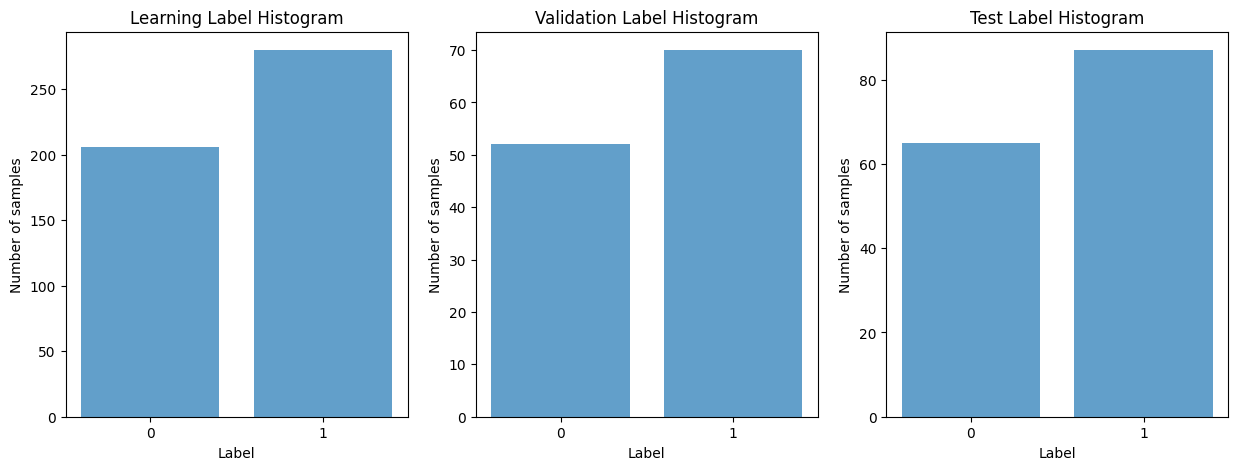

In [4]:
# split the entire dataset into training and test
labels = features.label
training, test = train_test_split(features, test_size=0.2, shuffle=True, random_state=0,
                                    stratify=labels)
training_labels = training.label

# further split training set into training and val
learning, validation = train_test_split(training, test_size=0.2,
                                     shuffle=True, stratify=training_labels)

learning_labels = learning.label
learning_features = learning.drop(columns='label')

validation_labels = validation.label
validation_features = validation.drop(columns='label')

test_labels = test.label
test_features = test.drop(columns='label')

# plot label histograms

# calculate the label counts for train, validation, and test sets
learning_label_counts = learning_labels.value_counts().sort_index()
validation_label_counts = validation_labels.value_counts().sort_index()
test_label_counts = test_labels.value_counts().sort_index()

# create subplots for the histograms
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# plot histograms for each dataset
ax1.bar(learning_label_counts.index, learning_label_counts.values, align='center', alpha=0.7)
ax1.set_xticks(learning_label_counts.index)
ax1.set_xlabel("Label")
ax1.set_ylabel("Number of samples")
ax1.set_title("Learning Label Histogram")
print('Total training patients: ' + str(np.shape(learning)[0]))


ax2.bar(validation_label_counts.index, validation_label_counts.values, align='center', alpha=0.7)
ax2.set_xticks(validation_label_counts.index)
ax2.set_xlabel("Label")
ax2.set_ylabel("Number of samples")
ax2.set_title("Validation Label Histogram")
print('Total validation patients: ' + str(np.shape(validation)[0]))


ax3.bar(test_label_counts.index, test_label_counts.values, align='center', alpha=0.7)
ax3.set_xticks(test_label_counts.index)
ax3.set_xlabel("Label")
ax3.set_ylabel("Number of samples")
ax3.set_title("Test Label Histogram")
print('Total test patients: ' + str(np.shape(test)[0]))


# **5.** Feature Tranformation & Selection
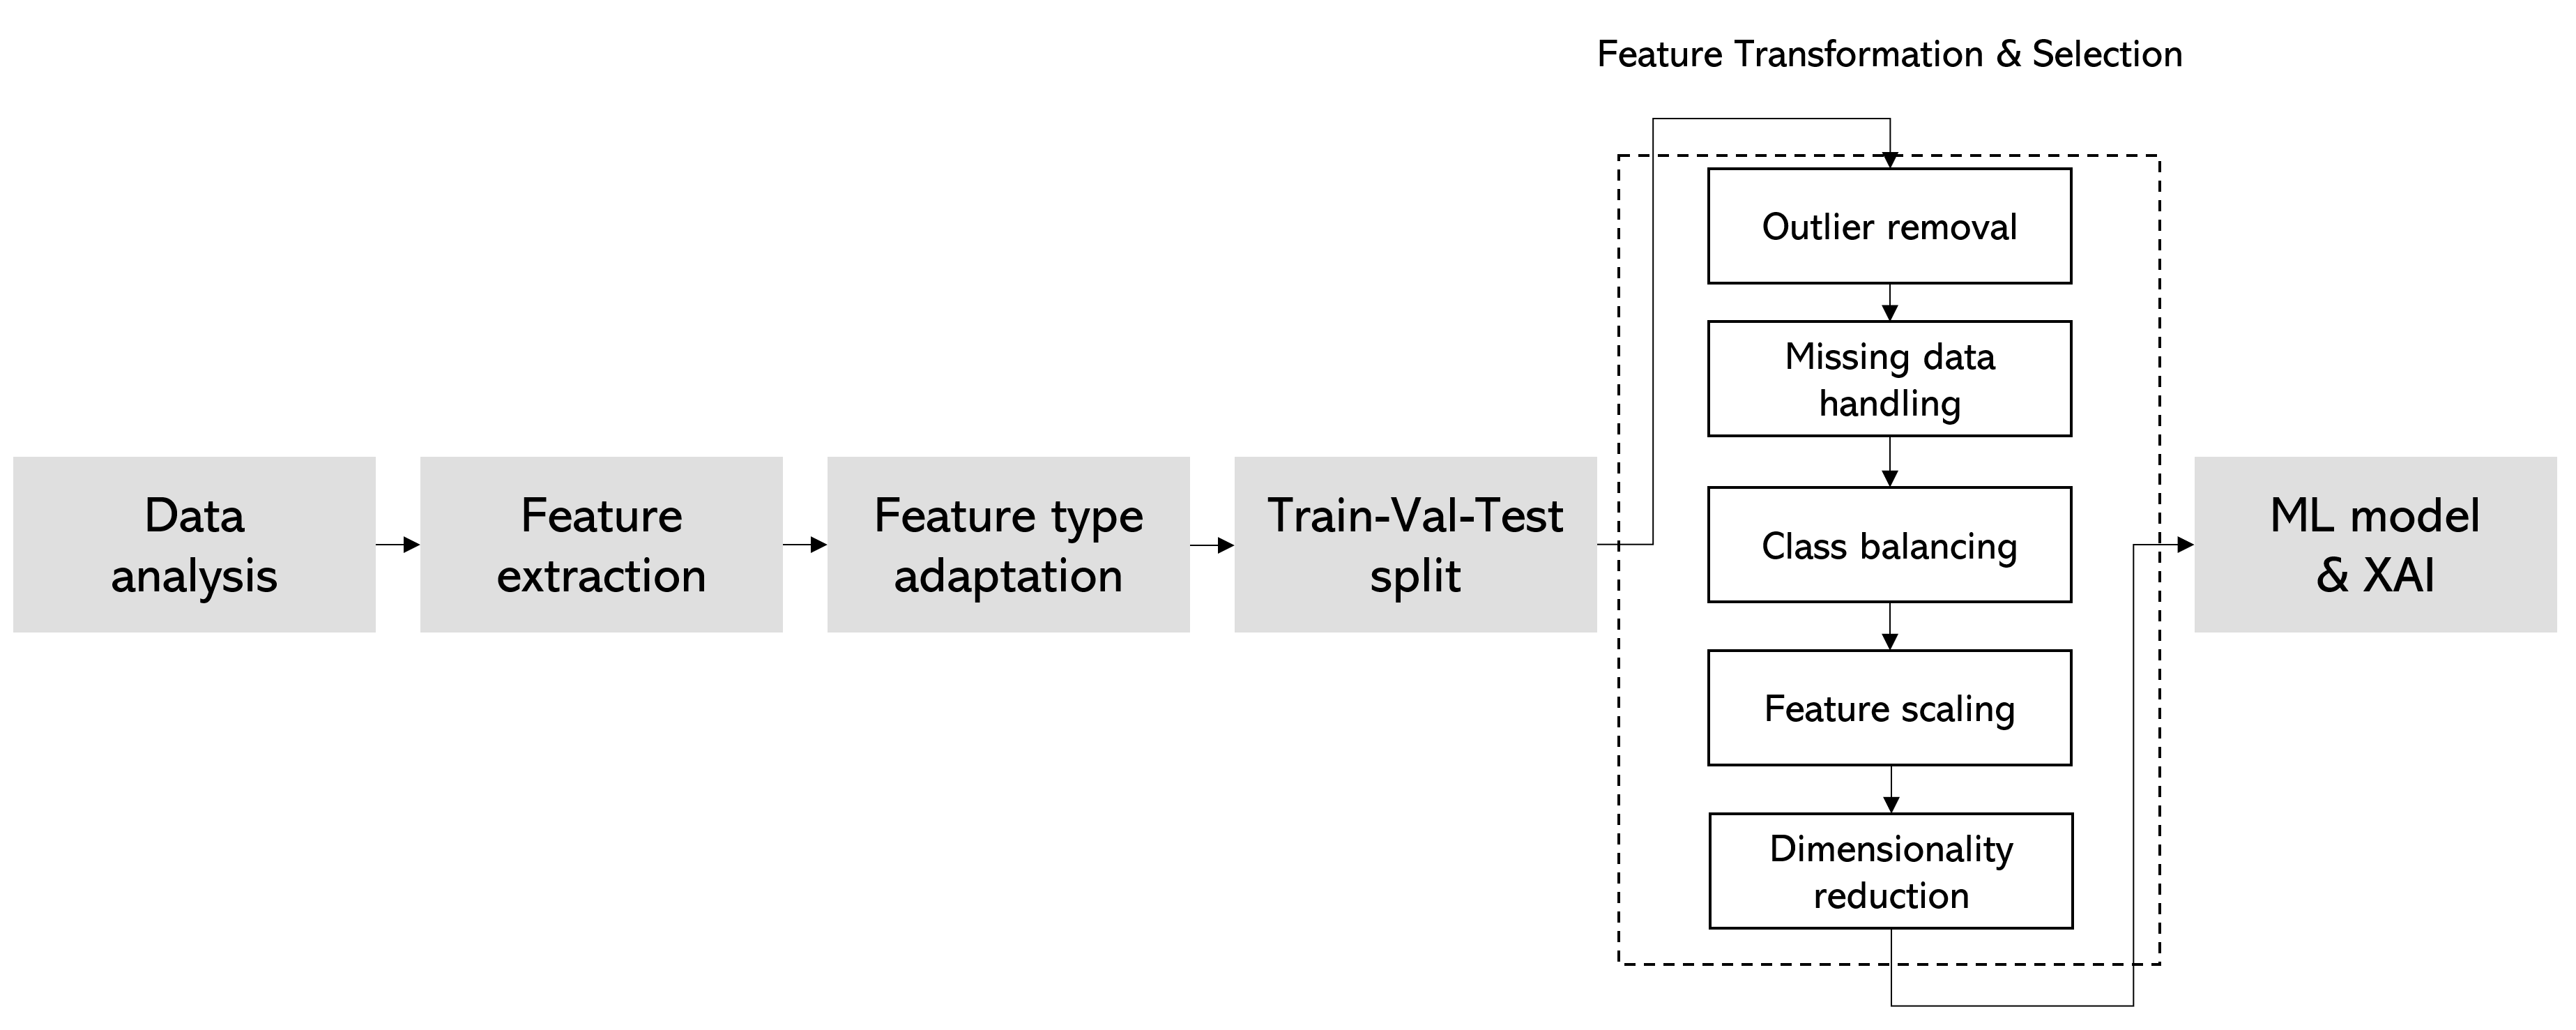

## **5.1.** Outliers' removal

*   method 1 --> z-score
*   method 2 --> IQR

**--> Let's check the distribution of the data to know which one we should use!**


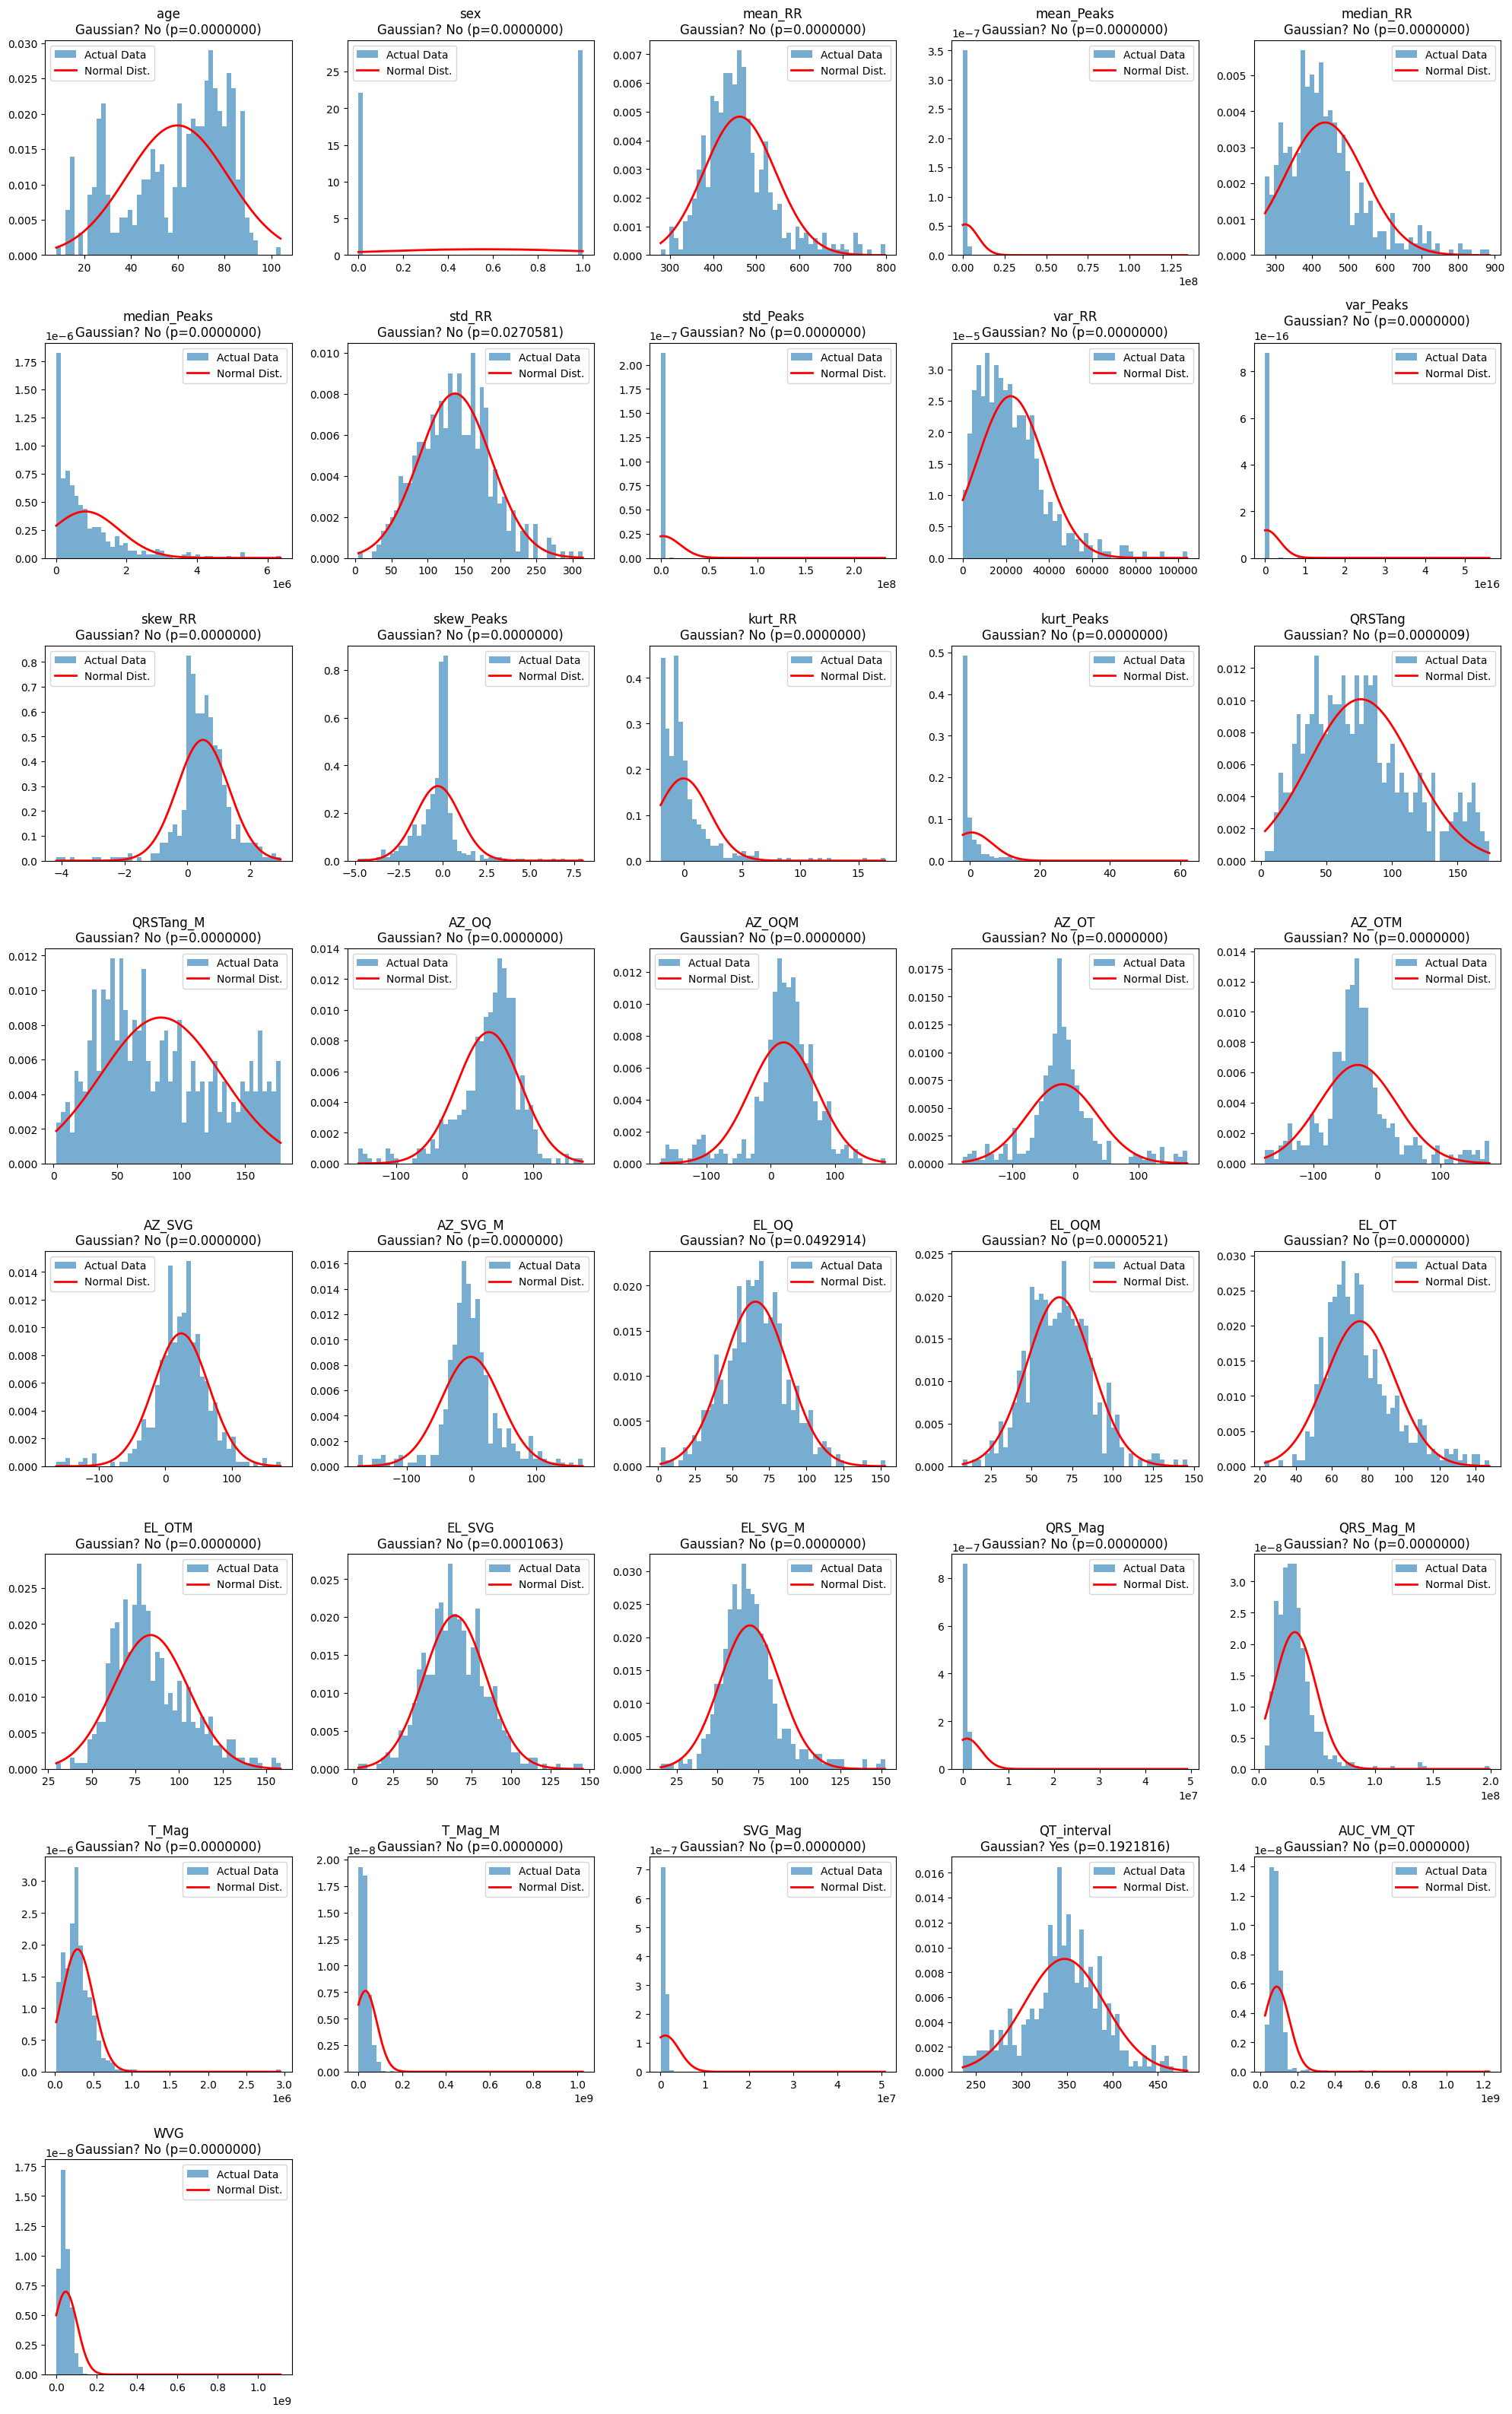

In [5]:
num_features = len(learning_features.columns)
cols_per_row = 5
rows = int(np.ceil(num_features / cols_per_row))

fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, 4 * rows))
axes = axes.flatten()  # Flatten in case of single row

for i, col in enumerate(learning_features.columns):
    data = learning_features[col].dropna()
    ax = axes[i]

    # Histogram
    ax.hist(data, bins=50, density=True, alpha=0.6, label='Actual Data')

    # Normal PDF overlay
    xs = np.linspace(data.min(), data.max(), 200)
    fit = stats.norm.pdf(xs, np.mean(data), np.std(data))
    ax.plot(xs, fit, 'r-', lw=2, label='Normal Dist.')

    # Normality Test (D'Agostino-Pearson normality test)
    # --> null hypothesis: data follows a Gaussian distribution
    stat, p = stats.normaltest(data)
    gaussian = 'Yes' if p > 0.05 else 'No'

    # Title
    ax.set_title(f"{col}\nGaussian? {gaussian} (p={p:.7f})")
    ax.legend()

# Hide unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**--> I cannot assume Gaussian distribution of the features --> IQR outliers' detection**

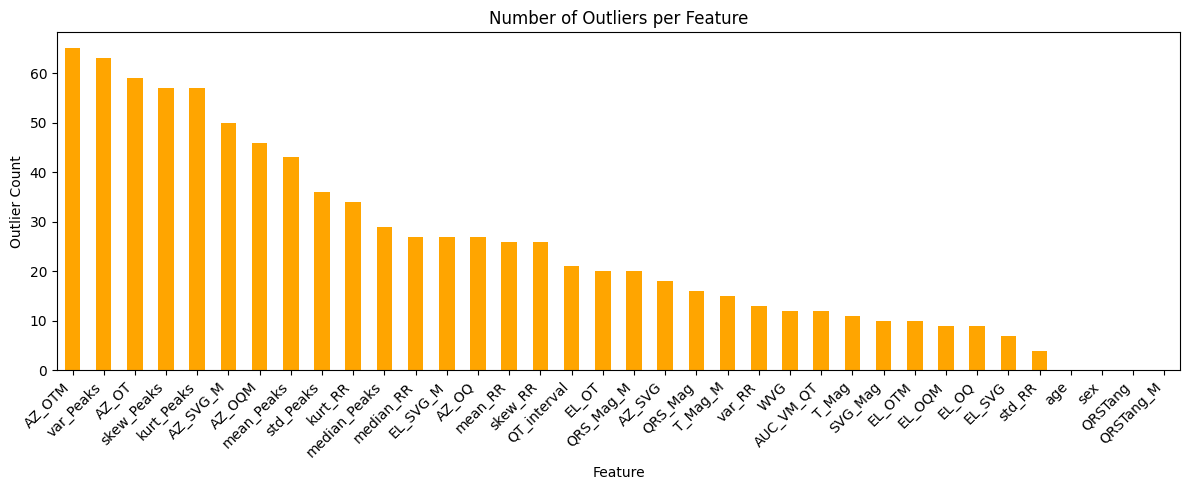

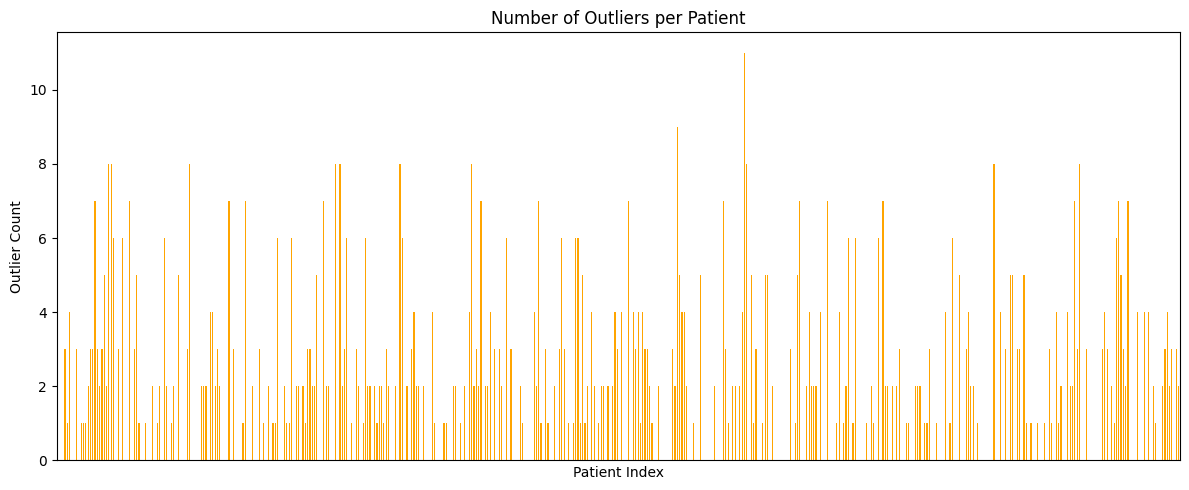

In [6]:
# Create a boolean DataFrame to store outlier flags
feature_list = learning_features.columns
outlier_flags = pd.DataFrame(False, index=learning_features.index, columns=feature_list)

# Dictionary to store bounds per feature;
# they will be used to identify outliers in validation and test set
iqr_bounds = {}

# IQR-based outlier detection
for col in feature_list:
    Q1 = learning_features[col].quantile(0.25)
    Q3 = learning_features[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Store values for later
    iqr_bounds[col] = (lower_bound, upper_bound)

    # Detect outliers
    outliers = (learning_features[col] < lower_bound) | (learning_features[col] > upper_bound)

    # Mark outliers in the flag DataFrame
    outlier_flags[col] = outliers

    # Replace outliers with NaN
    learning_features.loc[outliers, col] = np.nan

# Keep consistent DataFrame structure
learning_features = pd.DataFrame(data=learning_features, columns=feature_list)

# --------------------------
# Outliers per Feature
# --------------------------
plt.figure(figsize=(12, 5))
outlier_flags.sum().sort_values(ascending=False).plot(kind='bar', color='orange')
plt.title('Number of Outliers per Feature')
plt.xlabel('Feature')
plt.ylabel('Outlier Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --------------------------
# Outliers per Patient
# --------------------------
plt.figure(figsize=(12, 5))
outlier_flags.sum(axis=1).plot(kind='bar', color='orange')
plt.title('Number of Outliers per Patient')
plt.xlabel('Patient Index')
plt.ylabel('Outlier Count')
plt.xticks([])  # <-- this hides x-axis labels (indices)
plt.tight_layout()
plt.show()


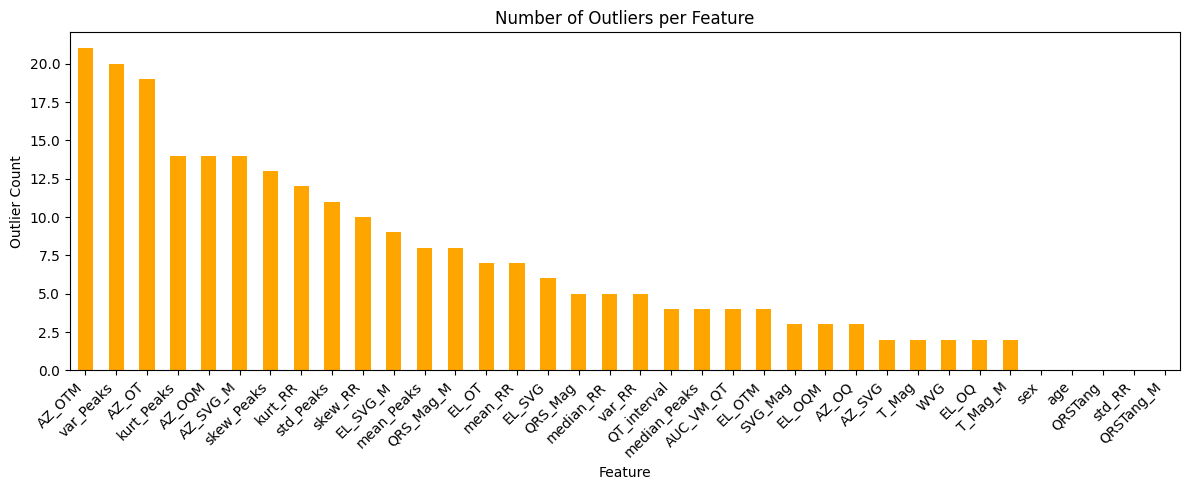

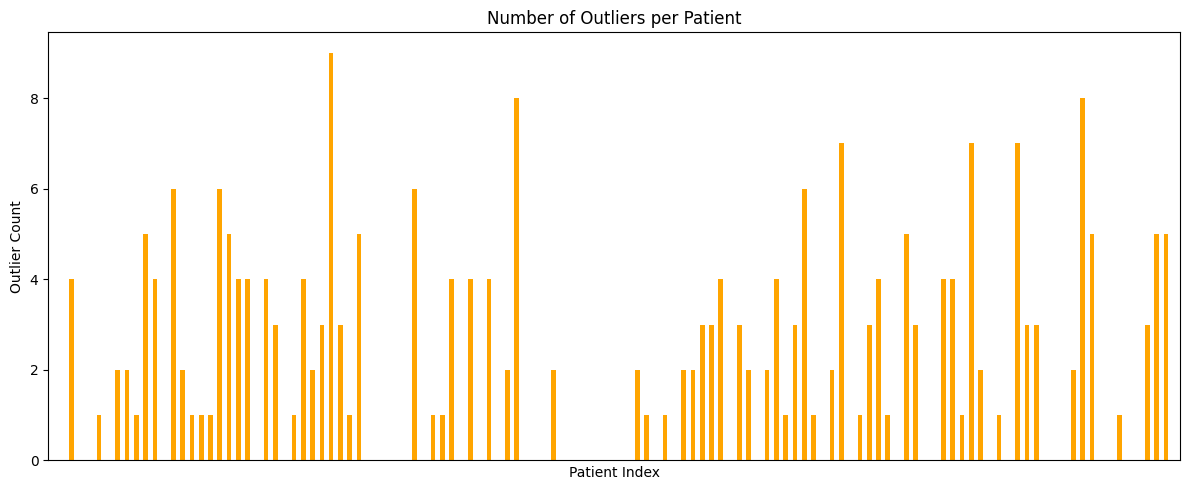

In [7]:
# Apply to validation set

outlier_flags = pd.DataFrame(False, index=validation_features.index, columns=validation_features.columns)

for col in validation_features.columns:
    lower_bound, upper_bound = iqr_bounds[col]
    outliers = (validation_features[col] < lower_bound) | (validation_features[col] > upper_bound)
    outlier_flags[col] = outliers
    validation_features.loc[outliers, col] = np.nan

validation_features =  pd.DataFrame(data=validation_features, columns=feature_list)

# --------------------------
# Outliers per Feature
# --------------------------
plt.figure(figsize=(12, 5))
outlier_flags.sum().sort_values(ascending=False).plot(kind='bar', color='orange')
plt.title('Number of Outliers per Feature')
plt.xlabel('Feature')
plt.ylabel('Outlier Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --------------------------
# Outliers per Patient
# --------------------------
plt.figure(figsize=(12, 5))
outlier_flags.sum(axis=1).plot(kind='bar', color='orange')
plt.title('Number of Outliers per Patient')
plt.xlabel('Patient Index')
plt.ylabel('Outlier Count')
plt.xticks([])  # <-- this hides x-axis labels (indices)
plt.tight_layout()
plt.show()

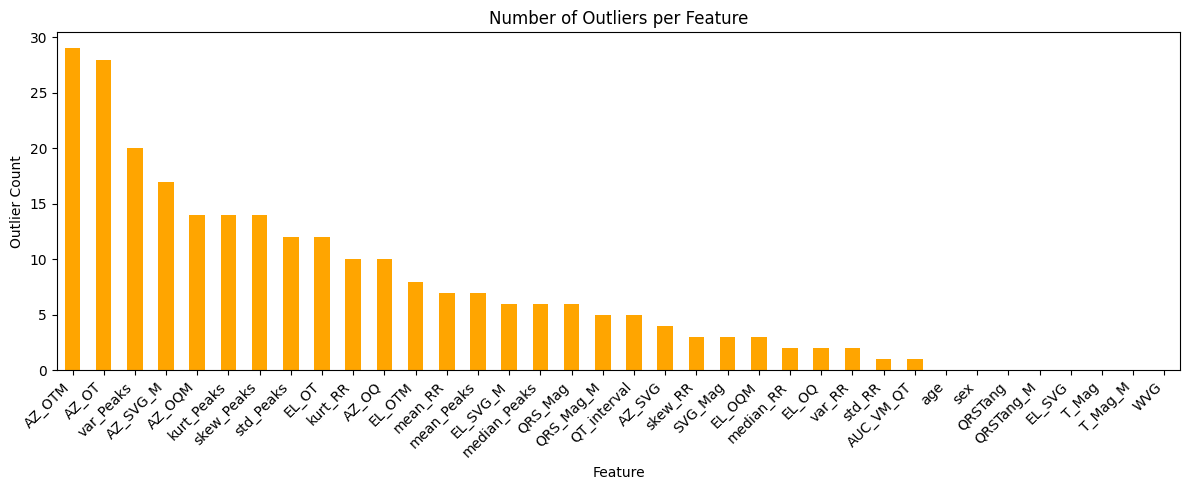

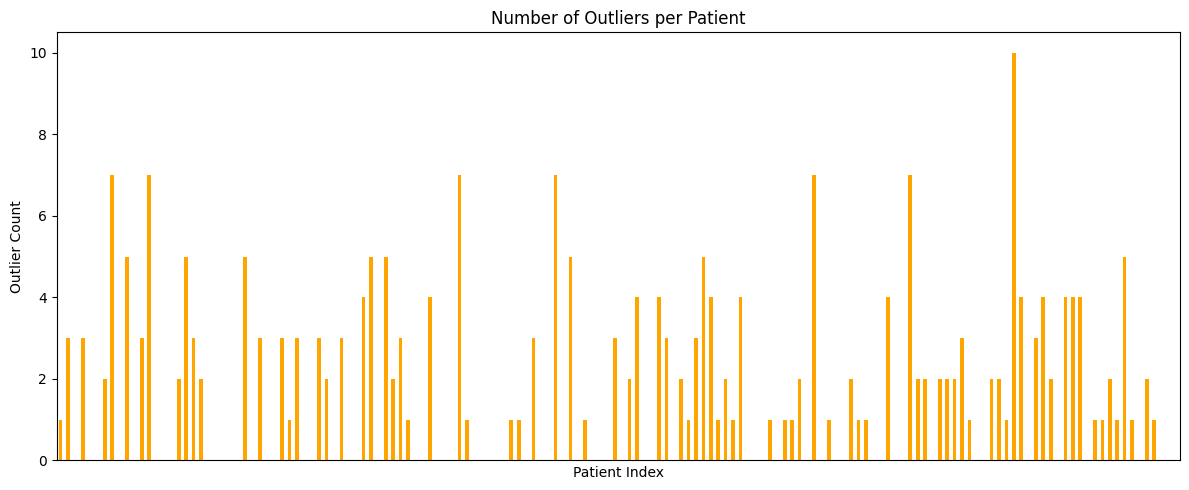

In [8]:
# Apply to test set

outlier_flags = pd.DataFrame(False, index=test_features.index, columns=test_features.columns)
for col in test_features.columns:
    lower_bound, upper_bound = iqr_bounds[col]
    outliers = (test_features[col] < lower_bound) | (test_features[col] > upper_bound)
    outlier_flags[col] = outliers
    test_features.loc[outliers, col] = np.nan

test_features =  pd.DataFrame(data=test_features, columns=feature_list)

# --------------------------
# Outliers per Feature
# --------------------------
plt.figure(figsize=(12, 5))
outlier_flags.sum().sort_values(ascending=False).plot(kind='bar', color='orange')
plt.title('Number of Outliers per Feature')
plt.xlabel('Feature')
plt.ylabel('Outlier Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --------------------------
# Outliers per Patient
# --------------------------
plt.figure(figsize=(12, 5))
outlier_flags.sum(axis=1).plot(kind='bar', color='orange')
plt.title('Number of Outliers per Patient')
plt.xlabel('Patient Index')
plt.ylabel('Outlier Count')
plt.xticks([])  # <-- this hides x-axis labels (indices)
plt.tight_layout()
plt.show()

## **5.2.** Missing data handling



Investigate the missing data distribution

In [9]:
# Compute the total number of missing values
total_missing = learning_features.isna().sum().sum()
total_values = np.shape(learning_features)[0] * np.shape(learning_features)[1] # rows*columns
print("Total missing values:", total_missing, "/", total_values)

Total missing values: 990 / 17496


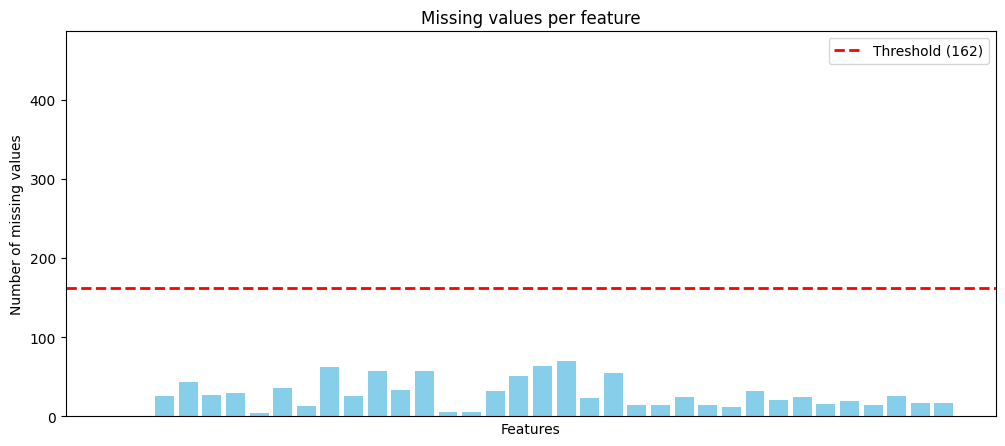

In [10]:
# Count missing values per feature (column)
missing_per_feature = learning_features.isna().sum(axis=0)

# Threshold: 1/3 of the total number of patients
max_missing_allowed = 1/3 * learning_features.shape[0]

plt.figure(figsize=(12, 5))

plt.bar(
    range(len(missing_per_feature)),
    missing_per_feature.values,
    color="skyblue"
)

plt.axhline(
    y=max_missing_allowed,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Threshold ({int(max_missing_allowed)})"
)

plt.xlabel("Features")
plt.ylabel("Number of missing values")
plt.ylim(0, learning_features.shape[0])
plt.title("Missing values per feature")

plt.xticks([])  # Remove feature names from x-axis
plt.legend()

plt.show()

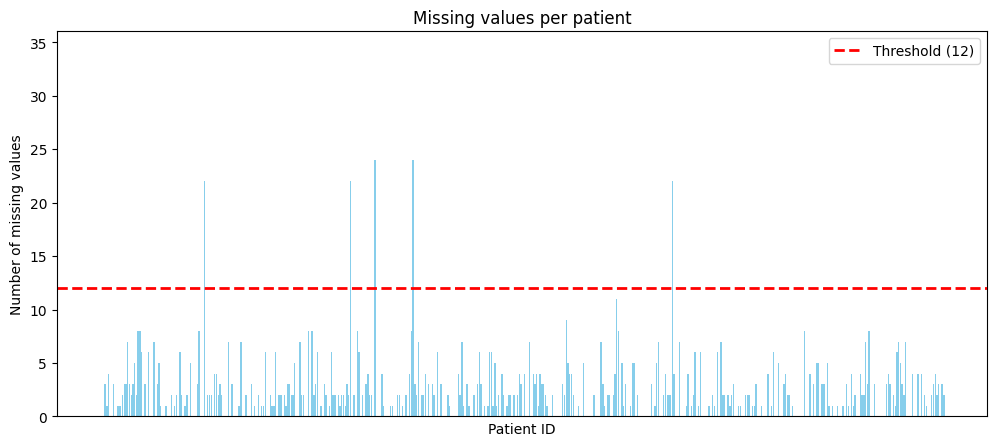

In [11]:
# Count missing values per patient (row)
missing_per_patient = learning_features.isna().sum(axis=1)
max_missing_allowed = 1/3 * np.shape(learning_features)[1]

plt.figure(figsize=(12,5))
plt.bar(missing_per_patient.index, missing_per_patient.values, color="skyblue")
plt.axhline(y=max_missing_allowed, color="red", linestyle="--", linewidth=2, label=f"Threshold ({int(max_missing_allowed)})")
plt.xlabel("Patient ID")
plt.ylabel("Number of missing values")
plt.ylim(0,np.shape(learning_features)[1])
plt.title("Missing values per patient")
plt.xticks([])  # rimuove i ticks dell’asse x
plt.legend()
plt.show()


### Listwise deletion
Delete patients with too many missing data



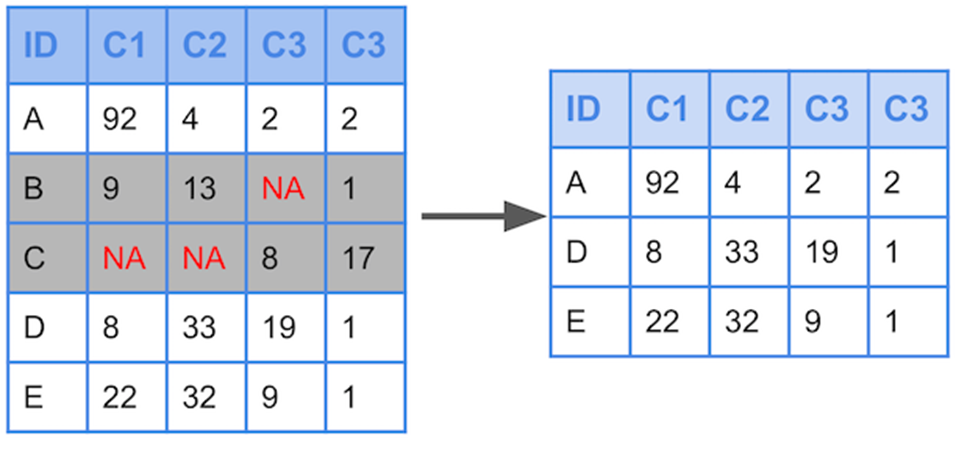

In [12]:
total_missing = learning_features.isna().sum().sum()
print("Missing data BEFORE listwise deletion:", total_missing)
print(f"Number of patients BEFORE listwise deletion: {learning_features.shape[0]} \n")

# Count missing values per patient (row)
missing_per_patient = learning_features.isna().sum(axis=1)

# Count the max number of missing values accepted per patient (no more than 1/3 of the total)
max_missing_allowed = 1/3 * np.shape(learning_features)[1]

# Select only patients that meet the criterion
learning_features_listwise = learning_features[missing_per_patient <= max_missing_allowed]
learning_labels_listwise = learning_labels[missing_per_patient <= max_missing_allowed]

total_missing = learning_features_listwise.isna().sum().sum()
print("Missing data AFTER listwise deletion:", total_missing)
print(f"Number of patients AFTER listwise deletion: {learning_features_listwise.shape[0]}")

Missing data BEFORE listwise deletion: 990
Number of patients BEFORE listwise deletion: 486 

Missing data AFTER listwise deletion: 876
Number of patients AFTER listwise deletion: 481


In [13]:
learning_features_listwise.shape

(481, 36)

In [14]:
learning_labels_listwise.shape

(481,)

**N.B. Deletion can be done just in the learning set! If a patient to be evaluated (in the validation phase or in the test phase) has missing data they have to be handled cause the patient cannot be discarded!**

The following step of imputation will be applied on learning, validation and test set.

### kNN imputation

In [15]:
# define imputer
imputer = KNNImputer(n_neighbors=10, weights='uniform', metric='nan_euclidean')

# fit on the learning set
imputer.fit(learning_features_listwise)

# extract features names
feature_list = learning_features_listwise.columns

# apply Imputer on learning, validation and test set
learning_features_knn = imputer.transform(learning_features_listwise)
learning_features_knn =  pd.DataFrame(data=learning_features_knn, columns=feature_list)
learning_labels_knn = learning_labels_listwise

validation_features_knn = imputer.transform(validation_features)
validation_features_knn =  pd.DataFrame(data=validation_features_knn, columns=feature_list)

test_features_knn = imputer.transform(test_features)
test_features_knn =  pd.DataFrame(data=test_features_knn, columns=feature_list)

# check if there are no missing data left
total_missing = learning_features_knn.isna().sum().sum()
print("Remaining missing data (LEARNING):", total_missing)

total_missing = validation_features_knn.isna().sum().sum()
print("Remaining missing data (VALIDATION):", total_missing)

total_missing = test_features_knn.isna().sum().sum()
print("Remaining missing data (TEST):", total_missing)


Remaining missing data (LEARNING): 0
Remaining missing data (VALIDATION): 0
Remaining missing data (TEST): 0


## **5.3.** Class balancing




Original class distribution: Counter({1: 277, 0: 204}) 




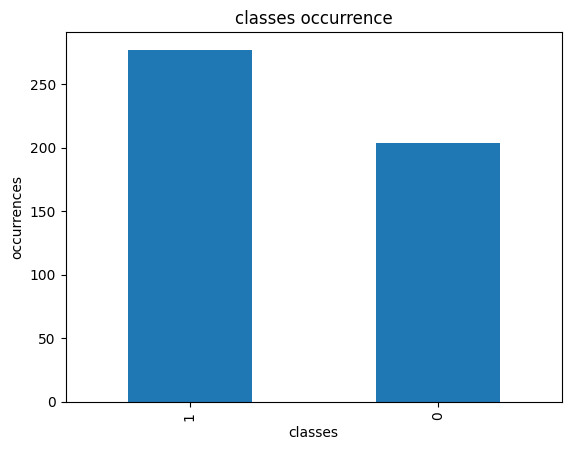

In [16]:
# Check the original class distribution
print("Original class distribution:", Counter(learning_labels_knn), "\n\n")

# Create label histogram using Counter and pandas Dataframe
label_counts = Counter(learning_labels_knn)
df = pd.DataFrame.from_dict(label_counts, orient='index')
df.plot(kind='bar', legend=False, title='classes occurrence', xlabel='classes', ylabel='occurrences')
plt.show()

**Which technique should I use?**

I can decide based on performance of a model (e.g. SVM) on the validation set

--> I'll choose the technique leading to the best results on the validation set

In [17]:
def testModel(learning_features, learning_labels, val_features, val_labels, model=svm.SVC(probability=True)):

    # Train the model
    model.fit(learning_features, learning_labels)

    # Predictions
    val_labels_pred = model.predict(val_features)
    val_probs = model.predict_proba(val_features)[:, 1]  # For AUC

    # Confusion matrix to get TN, FP, FN, TP
    cm = confusion_matrix(val_labels, val_labels_pred)
    tn, fp, fn, tp = cm.ravel()

    # Metrics
    accuracy = accuracy_score(val_labels, val_labels_pred)
    f1 = f1_score(val_labels, val_labels_pred)
    sensitivity = recall_score(val_labels, val_labels_pred)  # Same as recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc = roc_auc_score(val_labels, val_probs)

    # Print results
    print(f"Accuracy   : {accuracy:.4f}")
    print(f"F1-Score   : {f1:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"AUC        : {auc:.4f}\n\n")

    # Plot confusion matrix
    cm = confusion_matrix(val_labels, val_labels_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NSR', 'AF'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return


def testModel(
    learning_features,
    learning_labels,
    val_features,
    val_labels,
    model=svm.SVC(probability=True)
):

    # ============================================================
    # TRAIN MODEL
    # ============================================================
    model.fit(learning_features, learning_labels)


    # ============================================================
    # TRAINING SET
    # ============================================================

    # Predictions
    train_labels_pred = model.predict(learning_features)
    train_probs = model.predict_proba(learning_features)[:, 1]

    # Confusion matrix
    cm_train = confusion_matrix(learning_labels, train_labels_pred)
    tn, fp, fn, tp = cm_train.ravel()

    # Metrics
    train_accuracy = accuracy_score(learning_labels, train_labels_pred)
    train_f1 = f1_score(learning_labels, train_labels_pred)
    train_sensitivity = recall_score(learning_labels, train_labels_pred)
    train_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    train_auc = roc_auc_score(learning_labels, train_probs)

    # Print results
    print("=" * 40)
    print("TRAINING SET")
    print("=" * 40)
    print(f"Accuracy   : {train_accuracy:.4f}")
    print(f"F1-Score   : {train_f1:.4f}")
    print(f"Sensitivity: {train_sensitivity:.4f}")
    print(f"Specificity: {train_specificity:.4f}")
    print(f"AUC        : {train_auc:.4f}")

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_train,
        display_labels=['NSR', 'AF']
    )
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Training Set - Confusion Matrix")
    plt.tight_layout()
    plt.show()


    # ============================================================
    # VALIDATION SET
    # ============================================================

    # Predictions
    val_labels_pred = model.predict(val_features)
    val_probs = model.predict_proba(val_features)[:, 1]

    # Confusion matrix
    cm_val = confusion_matrix(val_labels, val_labels_pred)
    tn, fp, fn, tp = cm_val.ravel()

    # Metrics
    val_accuracy = accuracy_score(val_labels, val_labels_pred)
    val_f1 = f1_score(val_labels, val_labels_pred)
    val_sensitivity = recall_score(val_labels, val_labels_pred)
    val_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    val_auc = roc_auc_score(val_labels, val_probs)

    # Print results
    print("=" * 40)
    print("VALIDATION SET")
    print("=" * 40)
    print(f"Accuracy   : {val_accuracy:.4f}")
    print(f"F1-Score   : {val_f1:.4f}")
    print(f"Sensitivity: {val_sensitivity:.4f}")
    print(f"Specificity: {val_specificity:.4f}")
    print(f"AUC        : {val_auc:.4f}")

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_val,
        display_labels=['NSR', 'AF']
    )
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Validation Set - Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return

### ROS

In [18]:
ros = RandomOverSampler(random_state=42)
learning_features_ros, learning_labels_ros = ros.fit_resample(learning_features_knn, learning_labels_knn)
print("Class distribution before Oversampling:", Counter(learning_labels_knn))
print("Class distribution after Oversampling:", Counter(learning_labels_ros))

Class distribution before Oversampling: Counter({1: 277, 0: 204})
Class distribution after Oversampling: Counter({1: 277, 0: 277})


TRAINING SET
Accuracy   : 0.5939
F1-Score   : 0.5714
Sensitivity: 0.5415
Specificity: 0.6462
AUC        : 0.6236


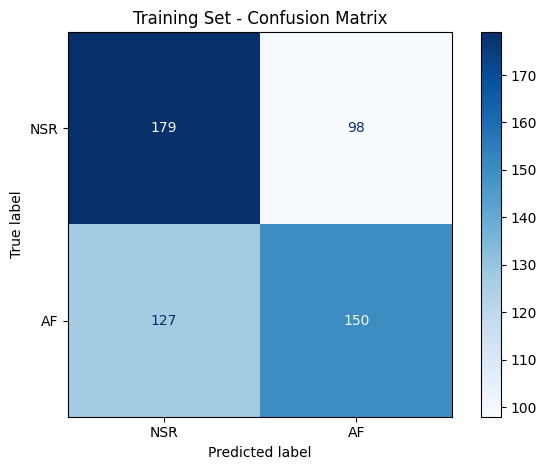

VALIDATION SET
Accuracy   : 0.5328
F1-Score   : 0.5440
Sensitivity: 0.4857
Specificity: 0.5962
AUC        : 0.5648


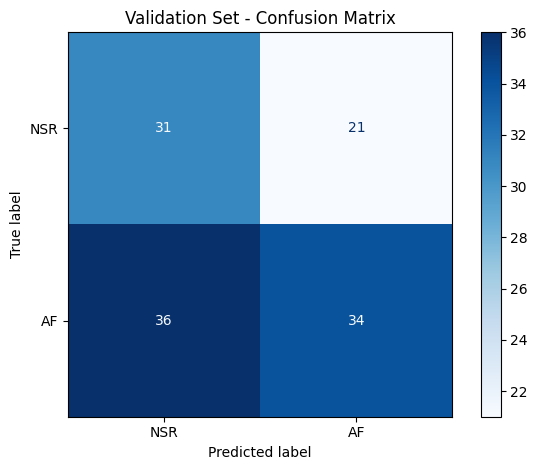

In [19]:
testModel(learning_features_ros, learning_labels_ros, validation_features_knn, validation_labels)

### SMOTE

In [20]:
smote = SMOTE(random_state=42)
learning_features_smote, learning_labels_smote = smote.fit_resample(learning_features_knn, learning_labels_knn)
print("Class distribution before SMOTE:", Counter(learning_labels_knn))
print("Class distribution after SMOTE:", Counter(learning_labels_smote))

Class distribution before SMOTE: Counter({1: 277, 0: 204})
Class distribution after SMOTE: Counter({1: 277, 0: 277})


TRAINING SET
Accuracy   : 0.5975
F1-Score   : 0.5687
Sensitivity: 0.5307
Specificity: 0.6643
AUC        : 0.6196


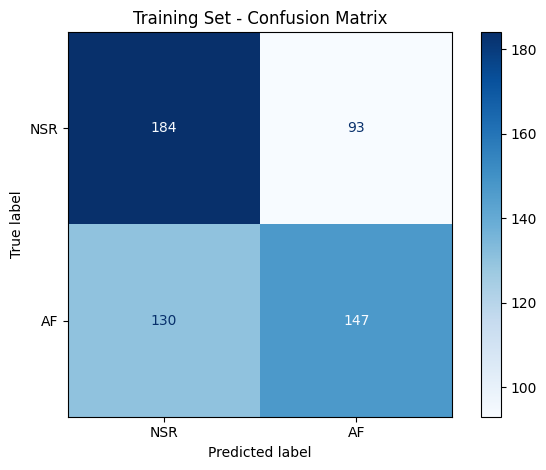

VALIDATION SET
Accuracy   : 0.5410
F1-Score   : 0.5410
Sensitivity: 0.4714
Specificity: 0.6346
AUC        : 0.5681


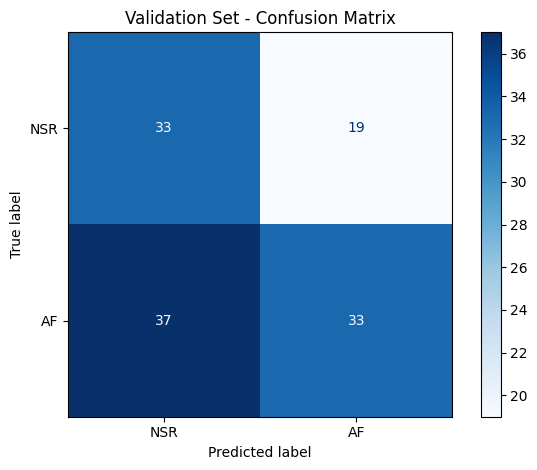

In [21]:
testModel(learning_features_smote, learning_labels_smote, validation_features_knn, validation_labels)

### RUS

In [22]:
rus = RandomUnderSampler(random_state=42)
learning_features_rus, learning_labels_rus = rus.fit_resample(learning_features_knn, learning_labels_knn)
print("Class distribution before Undersampling:", Counter(learning_labels_knn))
print("Class distribution after Undersampling:", Counter(learning_labels_rus))

Class distribution before Undersampling: Counter({1: 277, 0: 204})
Class distribution after Undersampling: Counter({0: 204, 1: 204})


TRAINING SET
Accuracy   : 0.6054
F1-Score   : 0.5818
Sensitivity: 0.5490
Specificity: 0.6618
AUC        : 0.6219


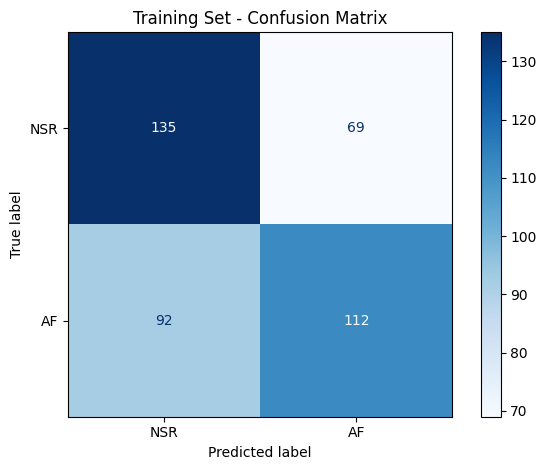

VALIDATION SET
Accuracy   : 0.5492
F1-Score   : 0.5455
Sensitivity: 0.4714
Specificity: 0.6538
AUC        : 0.5637


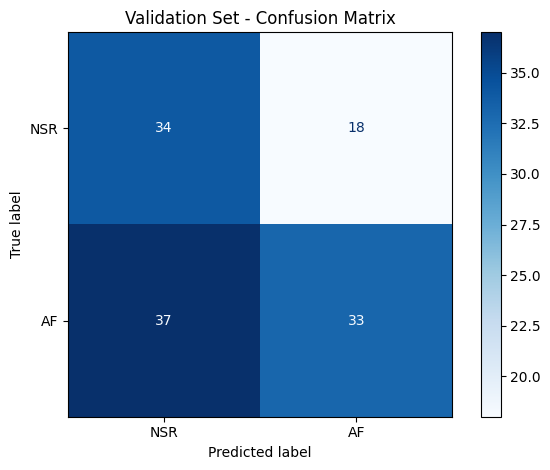

In [23]:
testModel(learning_features_rus, learning_labels_rus, validation_features_knn, validation_labels)

### NearMiss

In [24]:
nearmiss = NearMiss(version=1) # using NearMiss-1
learning_features_nm, learning_labels_nm = nearmiss.fit_resample(learning_features_knn, learning_labels_knn)
print("Class distribution before NearMiss:", Counter(learning_labels_knn))
print("Class distribution after NearMiss:", Counter(learning_labels_nm))

Class distribution before NearMiss: Counter({1: 277, 0: 204})
Class distribution after NearMiss: Counter({0: 204, 1: 204})


TRAINING SET
Accuracy   : 0.6642
F1-Score   : 0.6907
Sensitivity: 0.7500
Specificity: 0.5784
AUC        : 0.7361


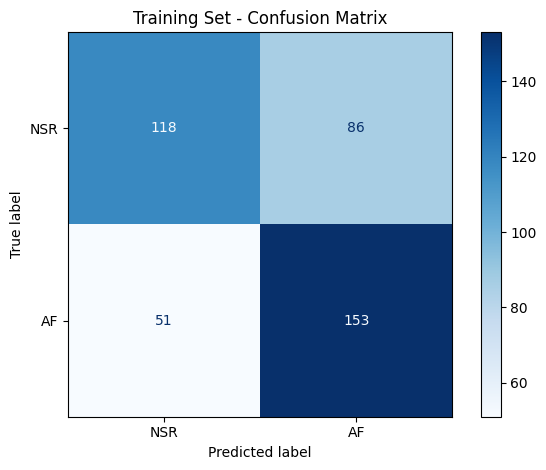

VALIDATION SET
Accuracy   : 0.5410
F1-Score   : 0.5625
Sensitivity: 0.5143
Specificity: 0.5769
AUC        : 0.5626


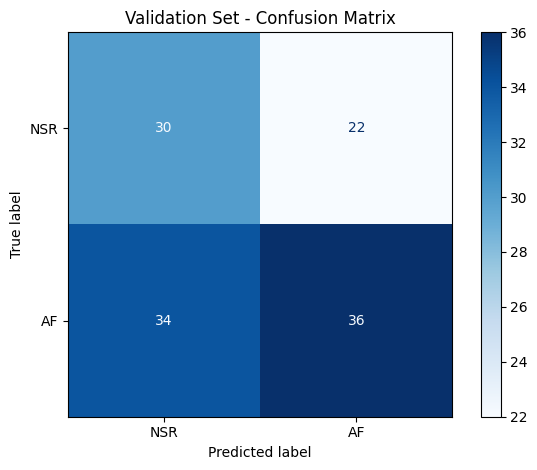

In [25]:
testModel(learning_features_nm, learning_labels_nm, validation_features_knn, validation_labels)

### Tomek links

In [26]:
tomek = TomekLinks()
learning_features_tomek, learning_labels_tomek = tomek.fit_resample(learning_features_knn, learning_labels_knn)
print("Class distribution before TomekLinks:", Counter(learning_labels_knn))
print("Class distribution after TomekLinks:", Counter(learning_labels_tomek))

Class distribution before TomekLinks: Counter({1: 277, 0: 204})
Class distribution after TomekLinks: Counter({1: 211, 0: 204})


TRAINING SET
Accuracy   : 0.6096
F1-Score   : 0.6029
Sensitivity: 0.5829
Specificity: 0.6373
AUC        : 0.6421


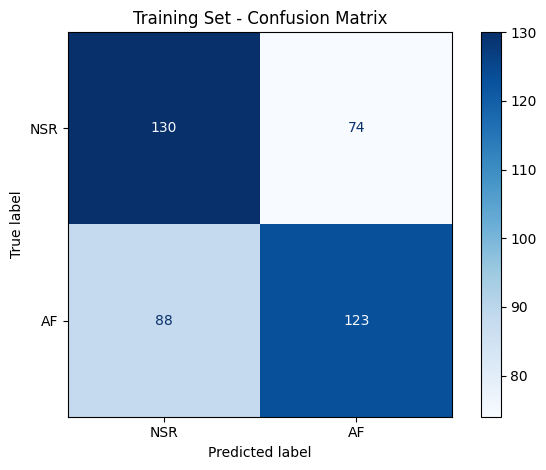

VALIDATION SET
Accuracy   : 0.5328
F1-Score   : 0.5440
Sensitivity: 0.4857
Specificity: 0.5962
AUC        : 0.5613


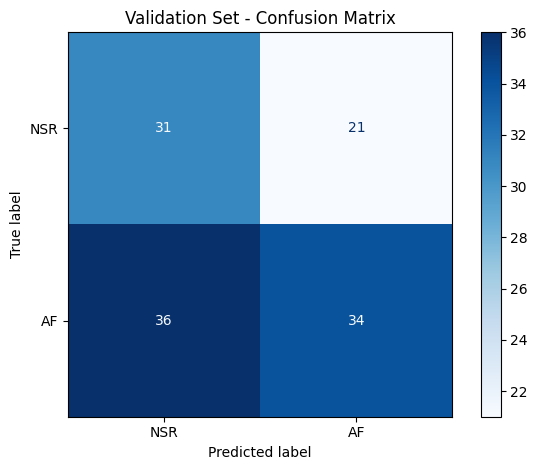

In [27]:
testModel(learning_features_tomek, learning_labels_tomek, validation_features_knn, validation_labels)

**Just use NearMiss-1**

## **5.4.** Feature scaling

**Since data distribution was not gaussian we apply MinMax scaling**

### Min-max scaling

In [28]:
# Copy the datasets
learning_features_minmax = learning_features_knn.copy()
learning_labels_minmax = learning_labels_knn.copy()

validation_features_minmax = validation_features_knn.copy()
test_features_minmax = test_features_knn.copy()

# Fit the scaler on the learning set only
scaler = MinMaxScaler(feature_range=(0, 1)) # for standard scaling use StandardScaler(), for RobustScaling use RobustScaler()
scaler.fit(learning_features_minmax)

# Transform learning set
feature_list = learning_features_minmax.columns
learning_features_minmax = scaler.transform(learning_features_minmax)
learning_features_minmax = pd.DataFrame(data=learning_features_minmax, columns=feature_list)

# Transform validation set
validation_features_minmax = scaler.transform(validation_features_minmax)
validation_features_minmax = pd.DataFrame(data=validation_features_minmax, columns=feature_list)

# Transform test set
test_features_minmax = scaler.transform(test_features_minmax)
test_features_minmax = pd.DataFrame(data=test_features_minmax, columns=feature_list)

# Display scaled learning set
learning_features_minmax


,age,sex,mean_RR,mean_Peaks,median_RR,median_Peaks,std_RR,std_Peaks,var_RR,var_Peaks,...,EL_SVG,EL_SVG_M,QRS_Mag,QRS_Mag_M,T_Mag,T_Mag_M,SVG_Mag,QT_interval,AUC_VM_QT,WVG
0,0.552083,0.0,0.590083,0.363157,0.403226,0.293574,0.388059,0.172375,0.210498,0.060306,...,0.605310,0.480235,0.444713,0.346245,0.361023,0.396681,0.460251,0.677083,0.446386,0.476845
1,0.072917,1.0,0.561065,0.218167,0.612903,0.015653,0.660241,0.359348,0.586741,0.255271,...,0.515838,0.437604,0.299077,0.239647,0.315772,0.201123,0.348589,0.406250,0.197537,0.300332
2,0.864583,1.0,0.375064,0.161988,0.150538,0.202968,0.649413,0.231102,0.565677,0.106473,...,0.476944,0.402755,0.533678,0.467198,0.493697,0.371548,0.597897,0.333333,0.399260,0.474402
3,0.406250,0.0,0.519691,0.613659,0.516129,0.533391,0.316817,0.332121,0.142597,0.218456,...,0.563469,0.569712,0.964049,0.820688,0.624557,0.934491,0.679442,0.520833,0.896540,0.712250
4,0.697917,0.0,0.645947,0.194639,0.467742,0.205290,0.634325,0.176224,0.545588,0.063124,...,0.071274,0.285901,0.246093,0.071235,0.480217,0.462948,0.368885,0.416667,0.478972,0.297895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,0.531250,0.0,0.438620,0.714160,0.252688,0.512135,0.415951,0.384941,0.239334,0.291886,...,0.433121,0.540473,0.253473,0.320682,0.529142,0.494529,0.429418,0.520833,0.320854,0.565072
477,0.250000,1.0,0.159681,0.150531,0.010753,0.074127,0.225434,0.237502,0.073674,0.110742,...,0.389604,0.493695,0.616495,0.869192,0.364917,0.503067,0.405762,0.729167,0.832551,0.123864
478,0.833333,1.0,0.721177,0.294998,0.532258,0.239835,0.470259,0.052820,0.302496,0.006210,...,0.564873,0.449362,0.579048,0.366885,0.524597,0.448528,0.573867,0.427083,0.445627,0.415833
479,0.447917,1.0,0.527648,0.380533,0.365591,0.381208,0.756792,0.334862,0.767776,0.222537,...,0.588639,0.158387,0.666594,0.653654,0.346545,0.166472,0.704787,0.062500,0.572418,0.324197


TRAINING SET
Accuracy   : 0.9439
F1-Score   : 0.9522
Sensitivity: 0.9711
Specificity: 0.9069
AUC        : 0.9900


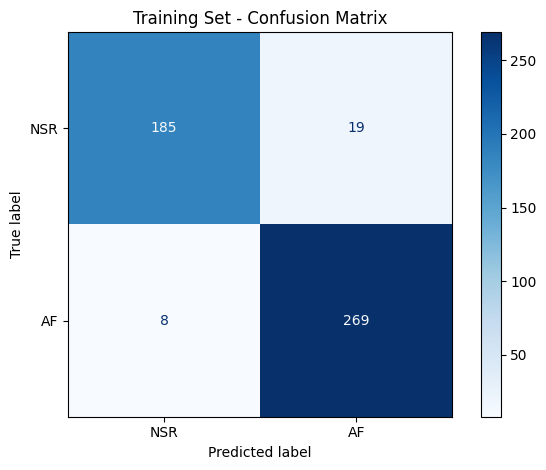

VALIDATION SET
Accuracy   : 0.8852
F1-Score   : 0.9041
Sensitivity: 0.9429
Specificity: 0.8077
AUC        : 0.9220


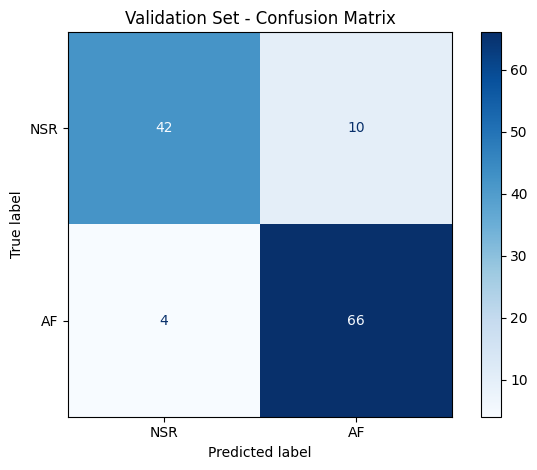

In [29]:
testModel(learning_features_minmax, learning_labels_minmax, validation_features_minmax, validation_labels)

## **5.5.** Dimensionality reduction


### Variance

I want to delete features with low variance.

Note: Since features are min-max scaled (scaled between 0 and 1), the variance will be a value between 0 and 1

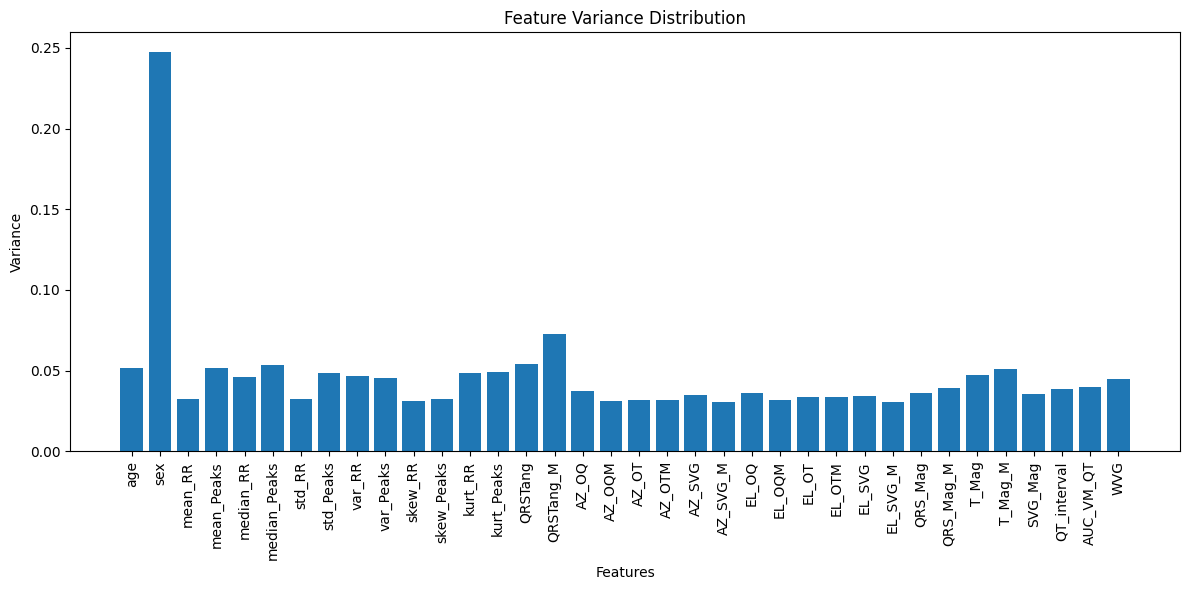

In [30]:
# Calculate variance for each feature
variances = learning_features_minmax.var()

# Plot
plt.figure(figsize=(12, 6))
plt.bar(range(len(variances)), variances.values)
plt.xticks(ticks=range(len(variances)), labels=variances.index, rotation=90)
plt.ylabel("Variance")
plt.xlabel("Features")
plt.title("Feature Variance Distribution")
plt.tight_layout()
plt.show()

In [31]:
# Print original feature count
print(len(learning_features_minmax.columns), "features before variance threshold (LEARNING)")

# Copy datasets
learning_features_var = learning_features_minmax.copy()
validation_features_var = validation_features_minmax.copy()
test_features_var = test_features_minmax.copy()

# Apply variance threshold
thresh = VarianceThreshold(threshold=0.0)
thresh.fit(learning_features_var)

# Get mask of non-constant features
mask = thresh.get_support()

# Filter columns using the mask
learning_features_var = learning_features_var.loc[:, mask]
validation_features_var = validation_features_var.loc[:, mask]
test_features_var = test_features_var.loc[:, mask]

# Print results
print(len(learning_features_var.columns), "features after variance threshold (LEARNING)")

# Print removed features
feature_list = learning_features_minmax.columns
removed_features = list(compress(feature_list, ~mask))
print("Deleted features:", removed_features)


36 features before variance threshold (LEARNING)
36 features after variance threshold (LEARNING)
Deleted features: []


### Correlation

We can note that patient and signal features are highly correlated among themselves, whereas morphological features are highly correlated among themselves. The two groups are scarcely correlated between each other.

In [32]:
def plot_correlationMatrix(correlation_matrix, features):
    fig, ax = plt.subplots(figsize=(8, 6))
    cax = ax.matshow(correlation_matrix)
    fig.colorbar(cax)
    ax.set_xticks(range(len(features)))
    ax.set_xticklabels(features, fontsize=10, rotation=90)
    ax.xaxis.set_ticks_position('bottom')
    ax.xaxis.set_label_position('bottom')
    ax.set_yticks(range(len(features)))
    ax.set_yticklabels(features, fontsize=10)
    plt.show()

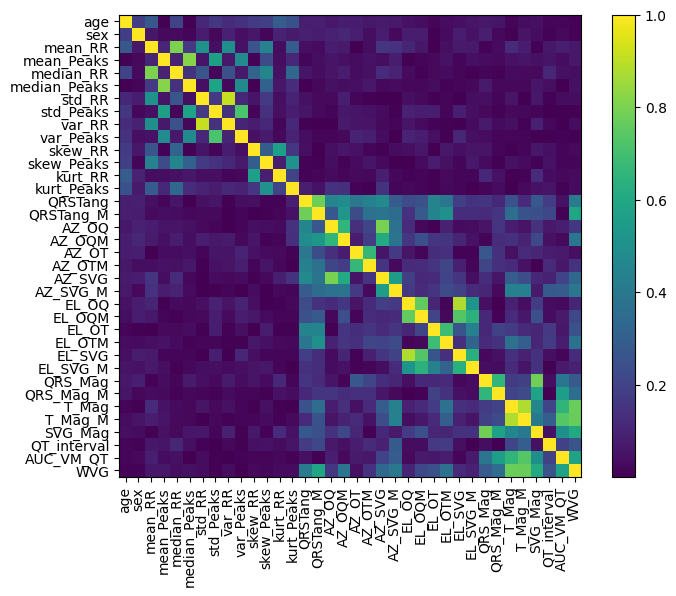

In [33]:
# Compute correlation matrix
corr_matrix = learning_features_var.corr().abs()
plot_correlationMatrix(corr_matrix, learning_features_var.columns.tolist())

In [34]:
# Identify and drop highly correlated features
def get_correlated_features(corr_matrix, threshold):

    # Initialize the set for storing correlated features
    correlated_features = set()

    # Get the upper triangle of the correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        # np.ones(corr_matrix.shape) --> create a matrix of ones with the same dimensions of corr_matrix
        # np.triu( , k=1) --> get just the upper part and exclude the diagonal
        # .astype(bool) --> convert 1 to True and 0 to False
        # corr_matrix.where() --> apply the boolean mask to corr_matrix

    # Find features with correlation greater than the threshold
    median_corr = corr_matrix.median(axis=0)  # calculates the median correlation of each feature with all other features
    to_drop = set()
    # feature 1
    for column in upper.columns:
        # feature 2
        for row in upper.index:
            # Proceed in the evalution if there's a correlation value and the correlation is > threshold
            if pd.notna(upper.loc[row, column]) and upper.loc[row, column] > threshold:
                # Drop the feature with the higher median correlation, because it is more likely redundant
                if median_corr[row] > median_corr[column]:
                    to_drop.add(row)
                else:
                    to_drop.add(column)

    return to_drop

In [35]:
print(len(learning_features_var.columns), "features before correlation threshold (LEARNING)")

# Copy dataset
learning_features_corr = learning_features_var.copy()

# Remove correlated features
correlated_features = get_correlated_features(corr_matrix, threshold=0.8)
learning_features_corr.drop(columns=correlated_features, inplace=True)
learning_labels_corr = learning_labels_minmax.copy()

print(len(learning_features_corr.columns), "features after correlation threshold (LEARNING)")


36 features before correlation threshold (LEARNING)
31 features after correlation threshold (LEARNING)


In [36]:
feature_list = learning_features_corr.columns

# Adapt validation set to keep only remaining features
validation_features_corr = validation_features_var[feature_list]
print(len(validation_features_corr.columns), "features after correlation threshold (VALIDATION)")

# Adapt test set too
test_features_corr = test_features_var[feature_list]
print(len(test_features_corr.columns), "features after correlation threshold (TEST)")


31 features after correlation threshold (VALIDATION)
31 features after correlation threshold (TEST)


TRAINING SET
Accuracy   : 0.9418
F1-Score   : 0.9505
Sensitivity: 0.9711
Specificity: 0.9020
AUC        : 0.9887


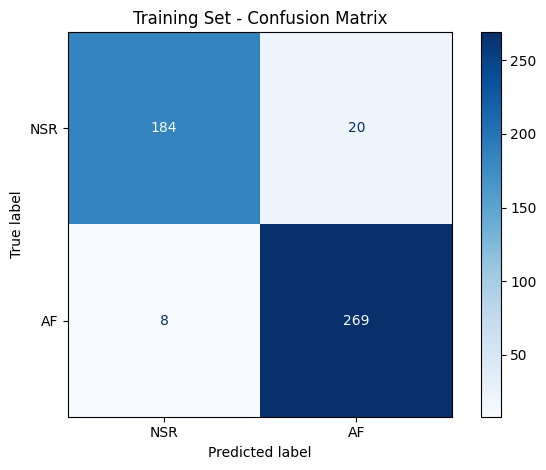

VALIDATION SET
Accuracy   : 0.8770
F1-Score   : 0.8966
Sensitivity: 0.9286
Specificity: 0.8077
AUC        : 0.9209


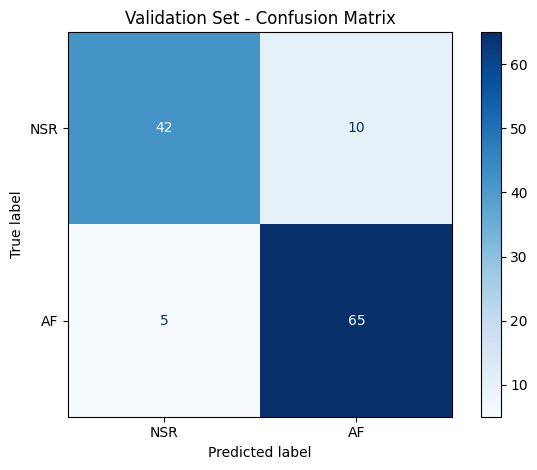

In [37]:
testModel(learning_features_corr, learning_labels_corr, validation_features_corr, validation_labels)

### LASSO

In [38]:
print(len(learning_features_corr.columns), "features before LASSO")

# Define the Lasso model
lasso = Lasso(alpha=0.01, random_state=SEED) # (alpha = constant controlling regularization strength)

# Operator that select non-zero coefficients
selector = SelectFromModel(lasso)

# Copy dataset
learning_features_lasso = learning_features_corr.copy()
learning_labels_lasso = learning_labels_corr.copy()

# Fit on learning data
selector.fit(learning_features_lasso, learning_labels_lasso)

# Get selected features
selected_features = learning_features_lasso.columns[selector.get_support()]

# Keep the selected features
learning_features_lasso = pd.DataFrame(selector.transform(learning_features_lasso), columns=selected_features)
validation_features_lasso = pd.DataFrame(selector.transform(validation_features_corr), columns=selected_features)
test_features_lasso = pd.DataFrame(selector.transform(test_features_corr), columns=selected_features)

print(len(learning_features_lasso.columns), "features after LASSO")

31 features before LASSO
4 features after LASSO


TRAINING SET
Accuracy   : 0.8877
F1-Score   : 0.9069
Sensitivity: 0.9495
Specificity: 0.8039
AUC        : 0.9560


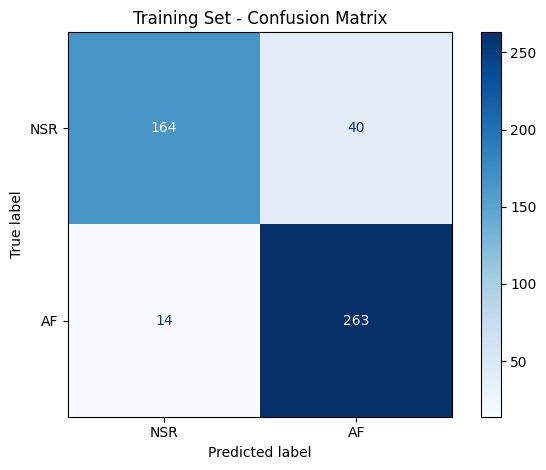

VALIDATION SET
Accuracy   : 0.8852
F1-Score   : 0.9054
Sensitivity: 0.9571
Specificity: 0.7885
AUC        : 0.9280


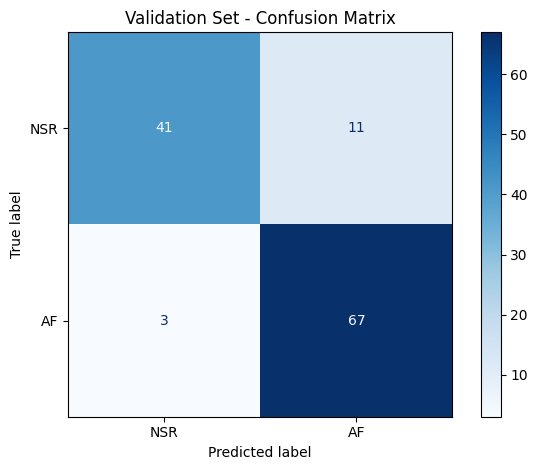

In [39]:
testModel(learning_features_lasso, learning_labels_lasso, validation_features_lasso, validation_labels)

### RFE

In [40]:
print(len(learning_features_corr.columns), "features before RFE")

# Define the estimator: SVM with linear kernel (needed for feature ranking)
estimator = SVC(kernel="linear")

# Define RFE (Recursive Feature Elimination) with 10 final features
selector = RFE(estimator=estimator, # model used to rank features
               n_features_to_select=10,  # number of features you want to keep
               step=1) # number of features to delete at each iteration

# Copy dataset
learning_features_rfe = learning_features_corr.copy()
learning_labels_rfe = learning_labels_corr.copy()
validation_features_rfe = validation_features_corr.copy()
test_features_rfe = test_features_corr.copy()

# Fit RFE on the learning set
selector.fit(learning_features_rfe, learning_labels_rfe)

# Get the names of the selected features
selected_features = learning_features_rfe.columns[selector.support_]

# Keep selected features
learning_features_rfe = learning_features_rfe[selected_features]
validation_features_rfe = validation_features_rfe[selected_features]
test_features_rfe = test_features_rfe[selected_features]

print(len(learning_features_rfe.columns), "features after RFE")

31 features before RFE
10 features after RFE


TRAINING SET
Accuracy   : 0.9252
F1-Score   : 0.9366
Sensitivity: 0.9603
Specificity: 0.8775
AUC        : 0.9758


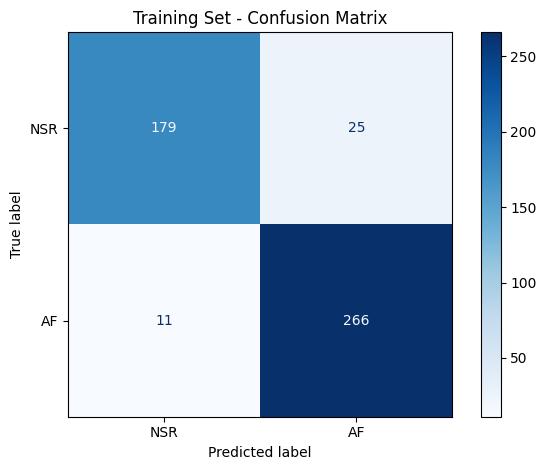

VALIDATION SET
Accuracy   : 0.9016
F1-Score   : 0.9178
Sensitivity: 0.9571
Specificity: 0.8269
AUC        : 0.9511


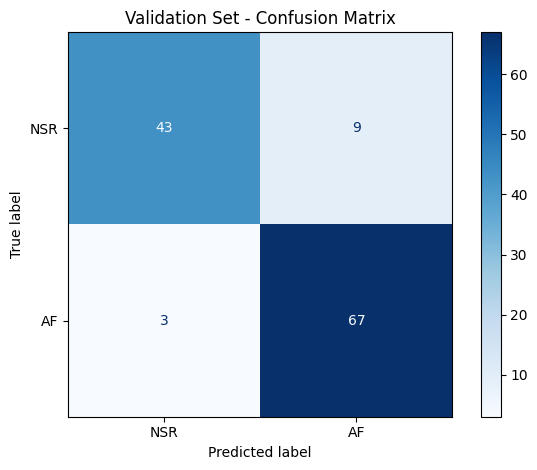

In [41]:
testModel(learning_features_rfe, learning_labels_rfe, validation_features_rfe, validation_labels)

**Let's choose RFE dataset as the final one**

In [42]:
learning_features = learning_features_rfe.copy()
learning_labels = learning_labels_rfe.copy()
validation_features = validation_features_rfe.copy()
test_features = test_features_rfe.copy()

In [43]:
learning_features

,age,std_RR,std_Peaks,skew_RR,skew_Peaks,kurt_RR,kurt_Peaks,AZ_OQM,EL_OTM,AUC_VM_QT
0,0.552083,0.388059,0.172375,0.531214,0.379701,0.192394,0.447164,0.432851,0.304608,0.446386
1,0.072917,0.660241,0.359348,0.408580,0.668311,0.068836,0.019779,0.497685,0.351830,0.197537
2,0.864583,0.649413,0.231102,0.845816,0.583269,0.676562,0.026387,0.643141,0.343988,0.399260
3,0.406250,0.316817,0.332121,0.308246,0.047365,0.128192,0.958318,0.372554,0.471689,0.896540
4,0.697917,0.634325,0.176224,0.483922,0.282069,0.168313,0.233846,0.983891,0.238506,0.478972
...,...,...,...,...,...,...,...,...,...,...
476,0.531250,0.415951,0.384941,0.673318,0.638901,0.393235,0.155566,0.211820,0.473303,0.320854
477,0.250000,0.225434,0.237502,0.417347,0.666381,0.055039,0.049825,0.605118,0.717354,0.832551
478,0.833333,0.470259,0.052820,0.647671,0.567641,0.398202,0.247472,0.720524,0.331787,0.445627
479,0.447917,0.756792,0.334862,0.134318,0.287004,0.172366,0.248688,0.306091,0.740683,0.572418


# **6.** ML classifier


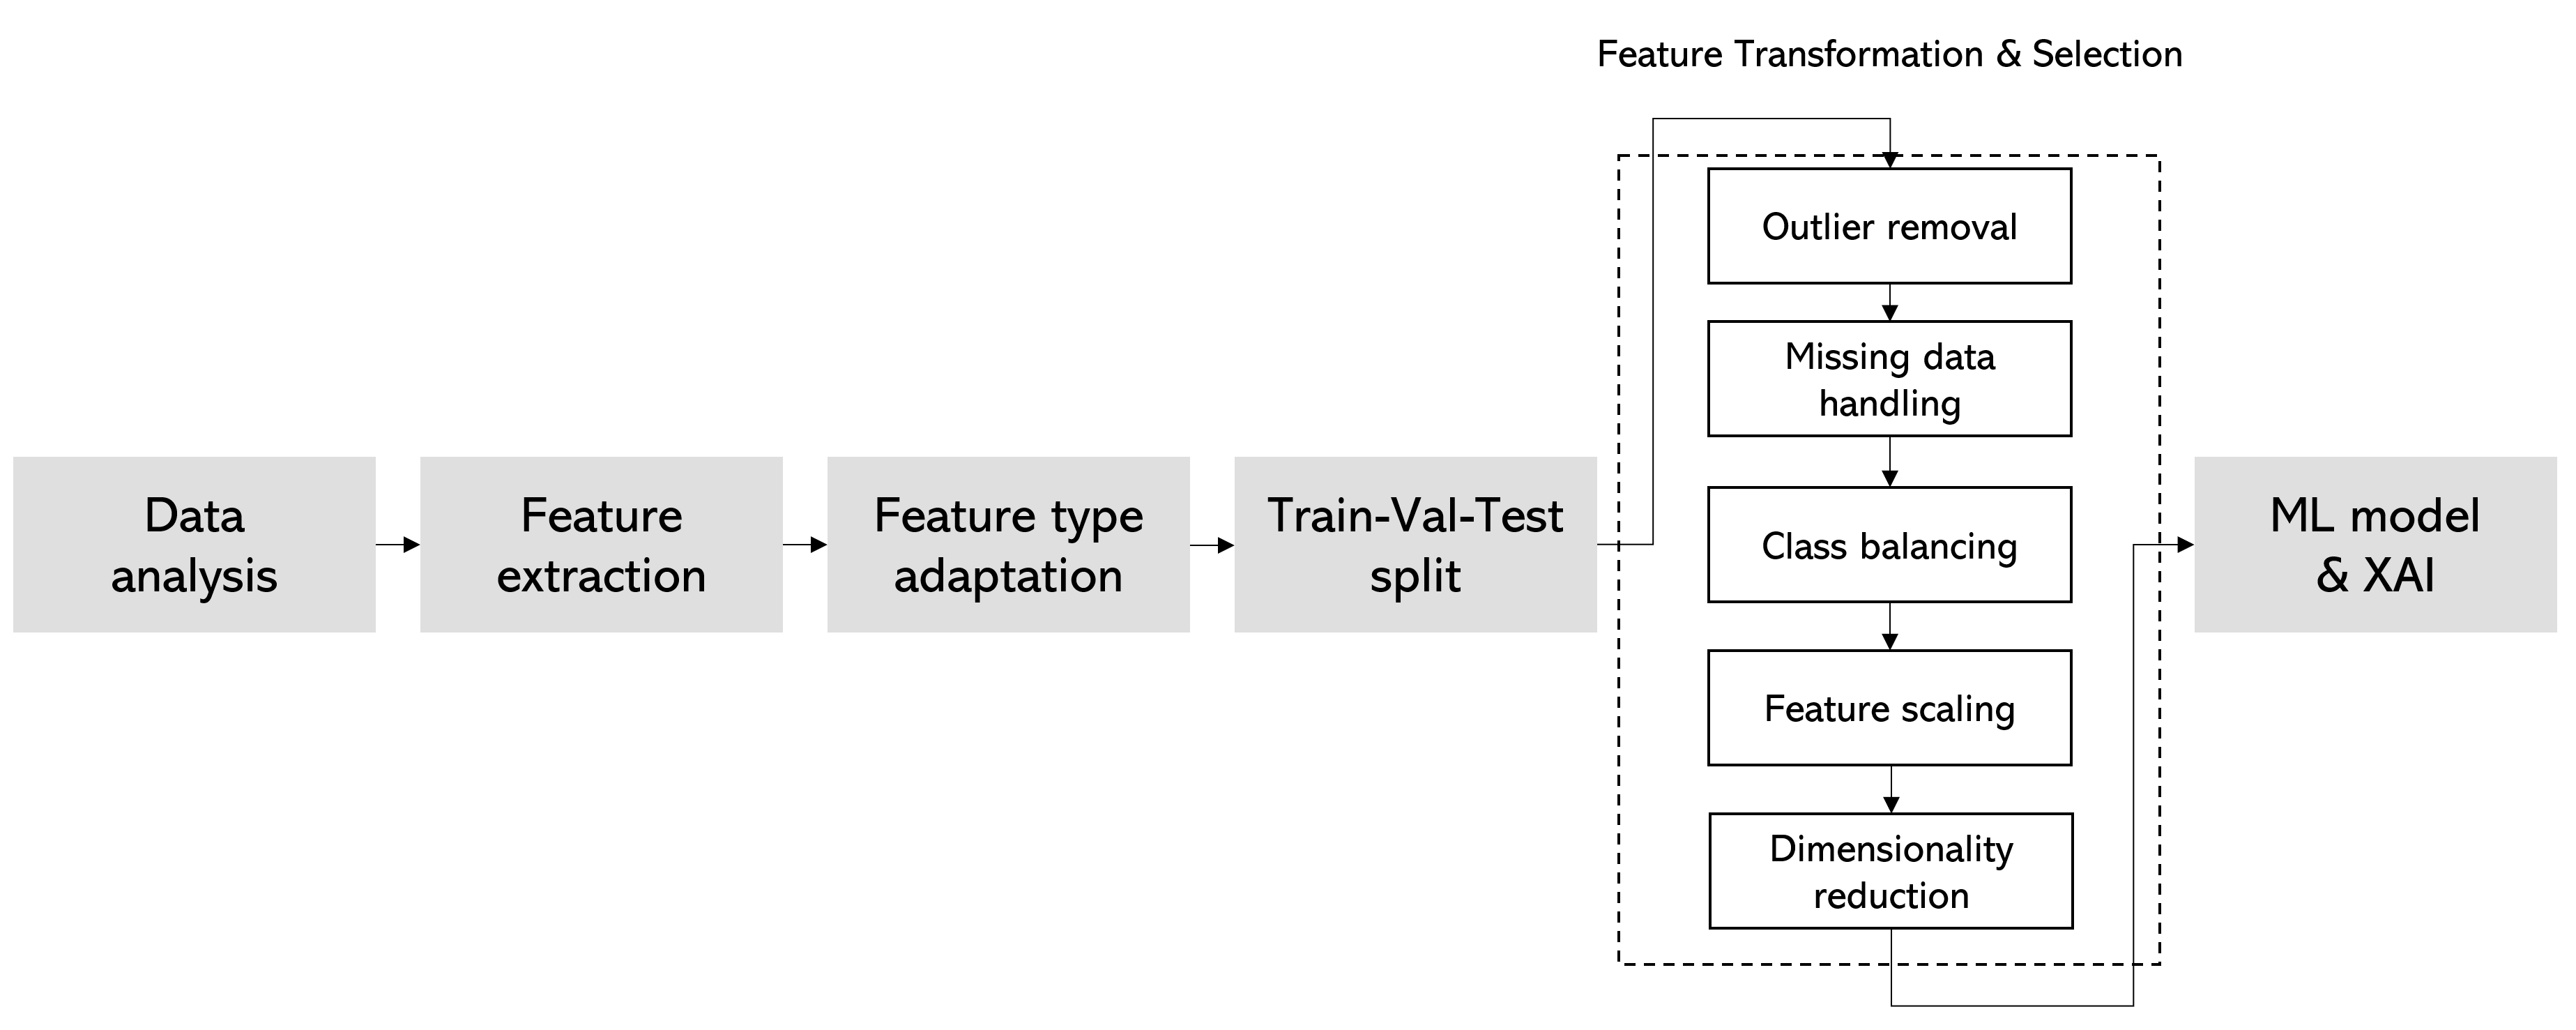

### Support vector machine (SVM)

TRAINING SET
Accuracy   : 0.9272
F1-Score   : 0.9372
Sensitivity: 0.9422
Specificity: 0.9069
AUC        : 0.9752


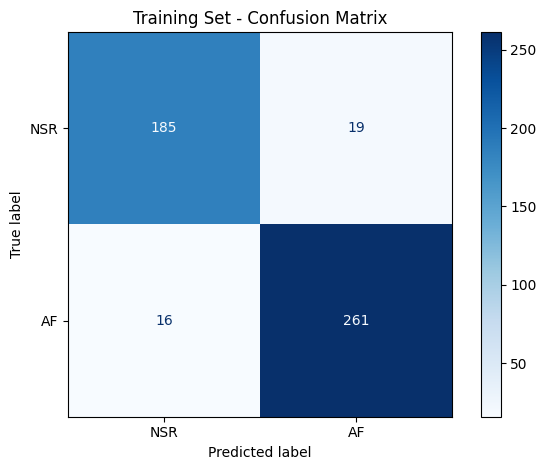

VALIDATION SET
Accuracy   : 0.8770
F1-Score   : 0.8921
Sensitivity: 0.8857
Specificity: 0.8654
AUC        : 0.9514


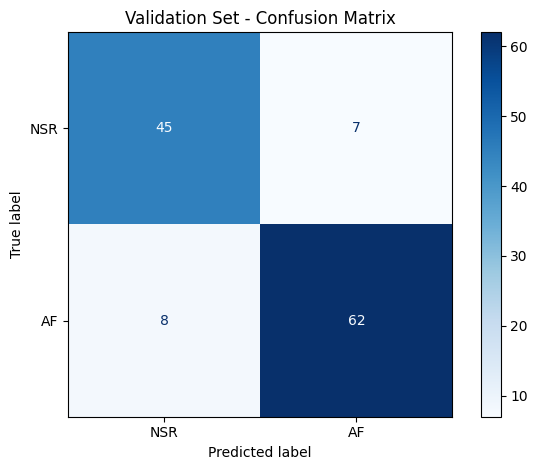

In [44]:
# Define model
clf_svm = svm.SVC(
    C=1.0,                       # Regularization parameter: lower = softer margin, higher = stricter margin
    kernel='rbf',                # Kernel type: 'rbf' (radial basis function / Gaussian)
    degree=3,                    # Degree for 'poly' kernel (ignored for 'rbf')
    gamma='scale',               # Kernel coefficient: 'scale' = 1 / (n_features * X.var())
    coef0=0.0,                   # Independent term in kernel function (used in 'poly' and 'sigmoid')
    shrinking=True,              # Whether to use the shrinking heuristic (usually improves performance)
    probability=True,           # Enable probability estimates (slower; needed for ROC, AUC)
    tol=0.001,                   # Stopping criterion tolerance
    cache_size=200,              # Size (in MB) of the kernel cache
    class_weight='balanced',     # Adjusts weights inversely proportional to class frequencies (handles imbalance)
    verbose=False,               # Enable verbose output during training (useful for debugging)
    max_iter=-1,                 # Max iterations (-1 = no limit)
    decision_function_shape='ovr',  # Strategy: 'ovr' = one-vs-rest, 'ovo' = one-vs-one
    break_ties=False             # If True, use confidence scores to break ties in multiclass (only with 'ovr')
)

# Evaluate on validation set
testModel(learning_features, learning_labels, validation_features, validation_labels, model=clf_svm)

### Logistic Regression

TRAINING SET
Accuracy   : 0.8960
F1-Score   : 0.9104
Sensitivity: 0.9170
Specificity: 0.8676
AUC        : 0.9485


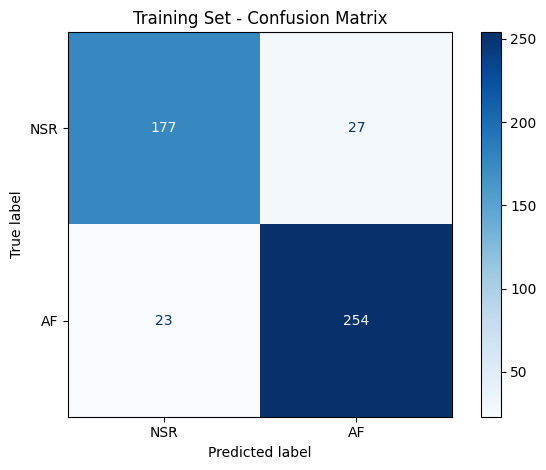

VALIDATION SET
Accuracy   : 0.8689
F1-Score   : 0.8857
Sensitivity: 0.8857
Specificity: 0.8462
AUC        : 0.9299


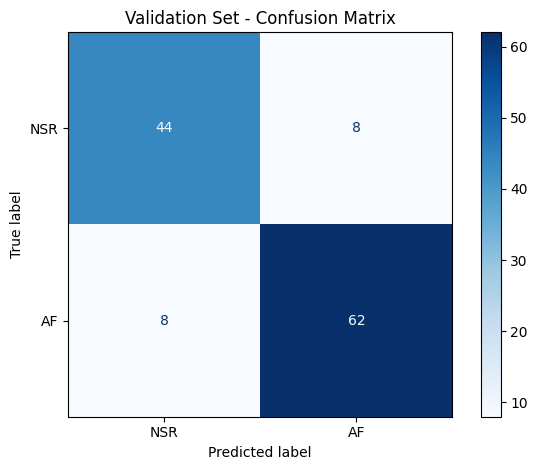

In [45]:
# Define model
clf_log = LogisticRegression(
    penalty='l2',             # L2 regularization
    C=1.0,                    # Regularization strength
    solver='lbfgs',           # Optimization algorithm
    max_iter=1000,            # Maximum iterations
    class_weight='balanced',  # Adjust weights inversely proportional to class frequencies
    random_state=42
)

# Test the model
testModel(learning_features, learning_labels, validation_features, validation_labels, model=clf_log)

### Ensembling

#### Bagging

TRAINING SET
Accuracy   : 0.9958
F1-Score   : 0.9964
Sensitivity: 0.9964
Specificity: 0.9951
AUC        : 0.9999


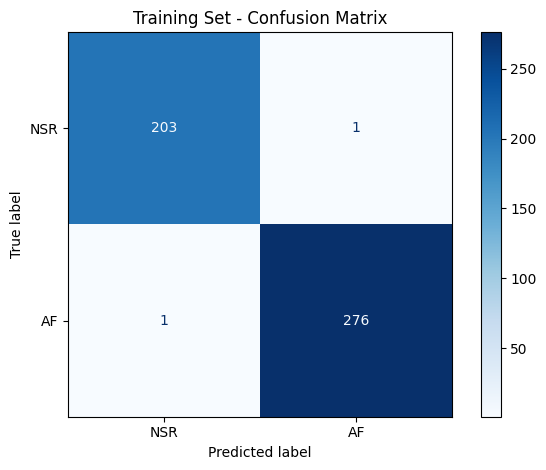

VALIDATION SET
Accuracy   : 0.8934
F1-Score   : 0.9091
Sensitivity: 0.9286
Specificity: 0.8462
AUC        : 0.9486


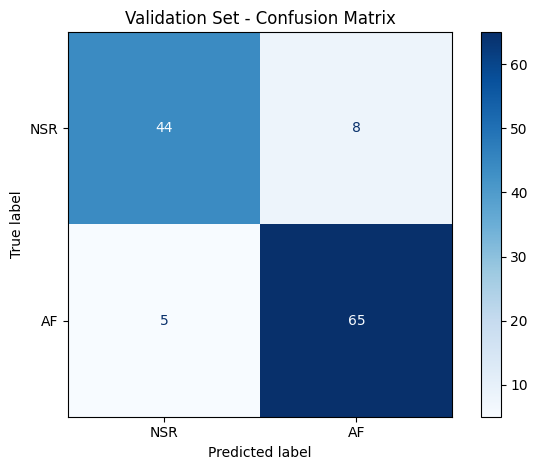

In [46]:
# Define the model
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(), # base model (using decision tree means building a Random Forest bagging model)
    n_estimators=50,       # Number of base models
    max_samples=0.8,       # Fraction of samples for each model
    max_features=0.8,      # Fraction of features for each model
    random_state=42,
    n_jobs=-1
)

# Evaluate the model
testModel(learning_features, learning_labels, validation_features, validation_labels, model=bagging_clf)

#### Boosting


TRAINING SET
Accuracy   : 0.8960
F1-Score   : 0.9158
Sensitivity: 0.9819
Specificity: 0.7794
AUC        : 0.9640


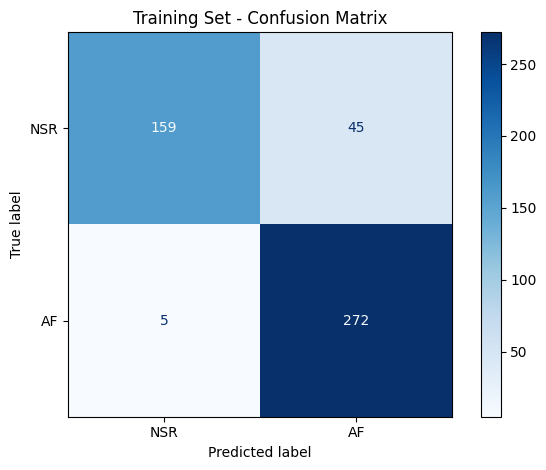

VALIDATION SET
Accuracy   : 0.8852
F1-Score   : 0.9067
Sensitivity: 0.9714
Specificity: 0.7692
AUC        : 0.9231


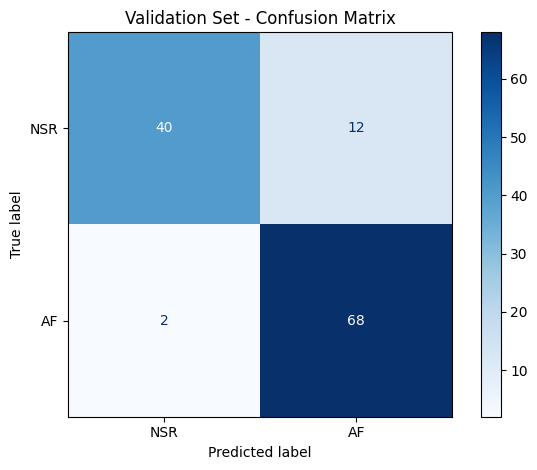

In [47]:
# Define the model
boosting_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# Evaluate the model
testModel(learning_features, learning_labels, validation_features, validation_labels, model=boosting_clf)

#### Stacking

TRAINING SET
Accuracy   : 0.9626
F1-Score   : 0.9677
Sensitivity: 0.9747
Specificity: 0.9461
AUC        : 0.9972


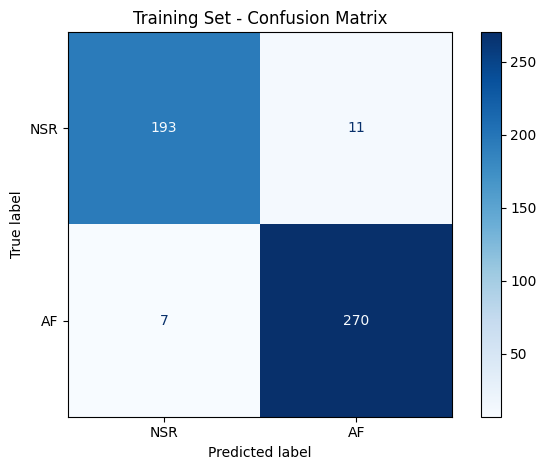

VALIDATION SET
Accuracy   : 0.8852
F1-Score   : 0.9014
Sensitivity: 0.9143
Specificity: 0.8462
AUC        : 0.9544


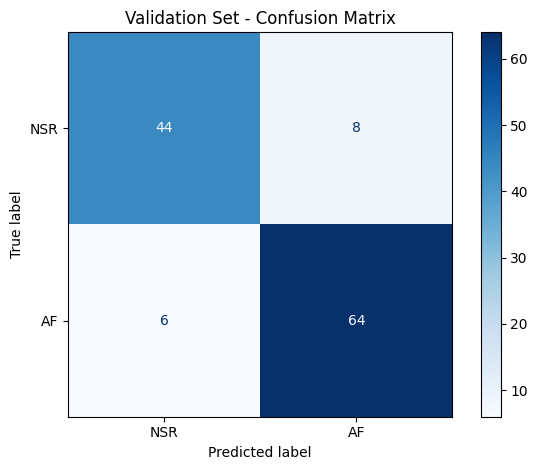

In [48]:
# Define base models
base_models = [
    ('logistic', LogisticRegression(
        penalty='l2',
        C=1.0,
        solver='lbfgs',
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    )),
    ('svm', SVC(
        C=1.0,
        kernel='rbf',
        gamma='scale',
        class_weight='balanced',
        probability=True,  # Required for stacking
        random_state=42
    )),
    ('random_forest', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
]

# Define stacking ensemble model
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    n_jobs=-1
)

# Evaluate the model
testModel(learning_features, learning_labels, validation_features, validation_labels, model=stacking_clf)

# **7.** Final model

**Let's choose Boosting option as final model**

TRAINING SET
Accuracy   : 0.8922
F1-Score   : 0.9134
Sensitivity: 0.9885
Specificity: 0.7617
AUC        : 0.9560


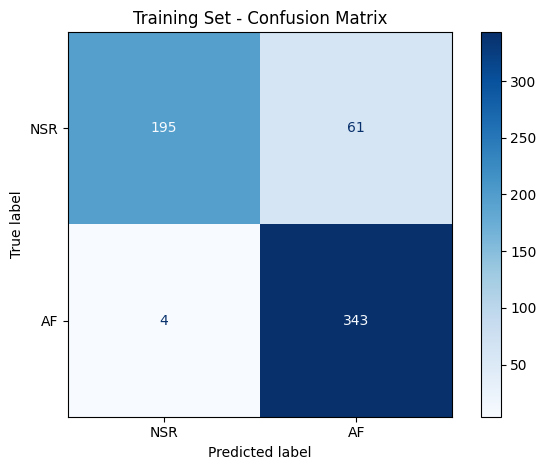

VALIDATION SET
Accuracy   : 0.9276
F1-Score   : 0.9405
Sensitivity: 1.0000
Specificity: 0.8308
AUC        : 0.9641


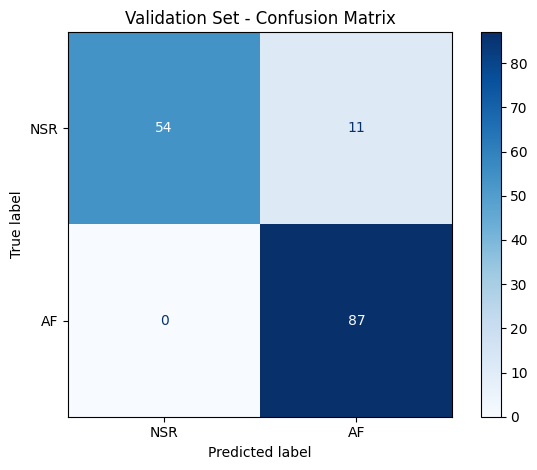

In [49]:
best_model = boosting_clf

# Combine train and validation sets
training_features = pd.concat([learning_features, validation_features])
training_labels = pd.concat([learning_labels, validation_labels])

# Re-train the model on training set (learning + validation) and evaluate the final model on test set
testModel(training_features, training_labels, test_features, test_labels, model=best_model)


# **8.** XAI

#### Permutation Importance




Permutation Importance:
      Feature  Importance
0         age    0.198728
5     kurt_RR    0.086033
6  kurt_Peaks    0.019246
1      std_RR    0.000000
3     skew_RR    0.000000
2   std_Peaks    0.000000
4  skew_Peaks    0.000000
7      AZ_OQM    0.000000
8      EL_OTM    0.000000
9   AUC_VM_QT    0.000000 




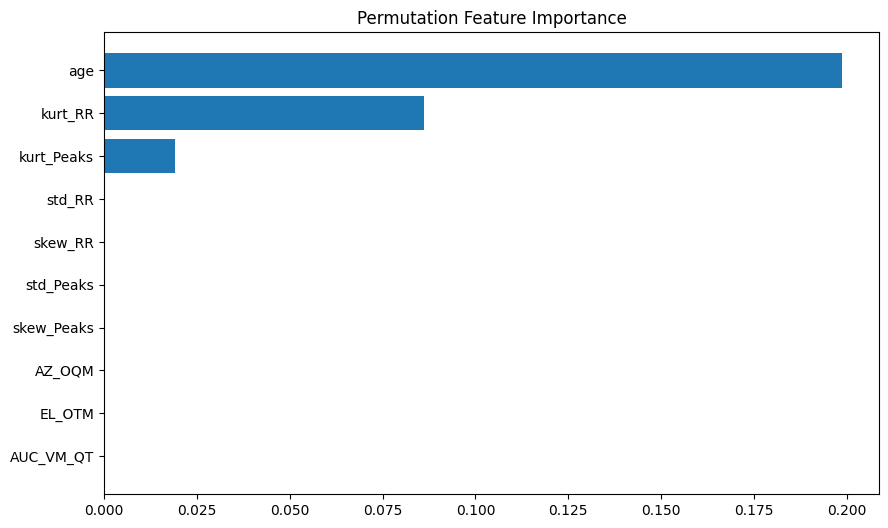

In [50]:
# Define permutation importance for each feature
perm_importance = permutation_importance(
    best_model,
    training_features,
    training_labels,
    n_repeats=10,
    random_state=42,
    scoring='f1_weighted'  # Use weighted F1 for imbalanced data
)

# Create a DataFrame for easier visualization
feature_names = training_features.columns
perm_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance.importances_mean
}).sort_values(by='Importance', ascending=False)

print("Permutation Importance:")
print(perm_df, "\n\n")

# Plot
plt.figure(figsize=(10,6))
plt.barh(perm_df['Feature'], perm_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Permutation Feature Importance")
plt.show()

#### Partial Dependence Plot
(let's analyze the 3 top features)

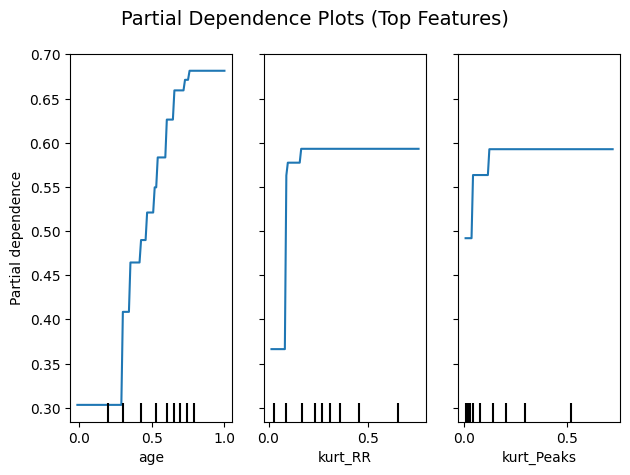

In [51]:
# Plot partial dependence for the top 3 important features
top_features = perm_df['Feature'].head(3).tolist()

PartialDependenceDisplay.from_estimator(
    best_model,
    training_features,          # Should be a DataFrame
    features=top_features,      # Can be names or indices
    kind='average',             # 'average' is standard; 'individual' shows all samples
    grid_resolution=100,        # Granularity of the plot
    n_jobs=-1                   # Use all cores
)

plt.suptitle("Partial Dependence Plots (Top Features)", fontsize=14)
plt.tight_layout()
plt.show()

#### SHAP

ExactExplainer explainer: 604it [03:06,  3.15it/s]
/tmp/ipykernel_5336/3473568058.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


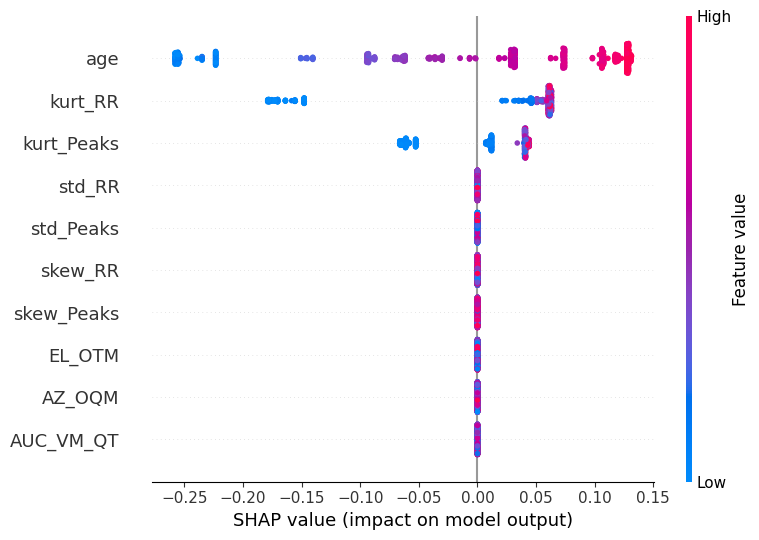

In [52]:
# Function that returns probability of the positive class
predict_fn = lambda X: best_model.predict_proba(X)[:, 1]

# Create SHAP explainer
explainer = shap.Explainer(
    predict_fn,
    training_features
)

# Compute SHAP values
shap_values = explainer(training_features)

# SHAP summary plot
feature_names = training_features.columns
shap.summary_plot(
    shap_values,
    training_features,
    feature_names=feature_names,
)



Explaining instance 0
True label:      1
Predicted label: 1


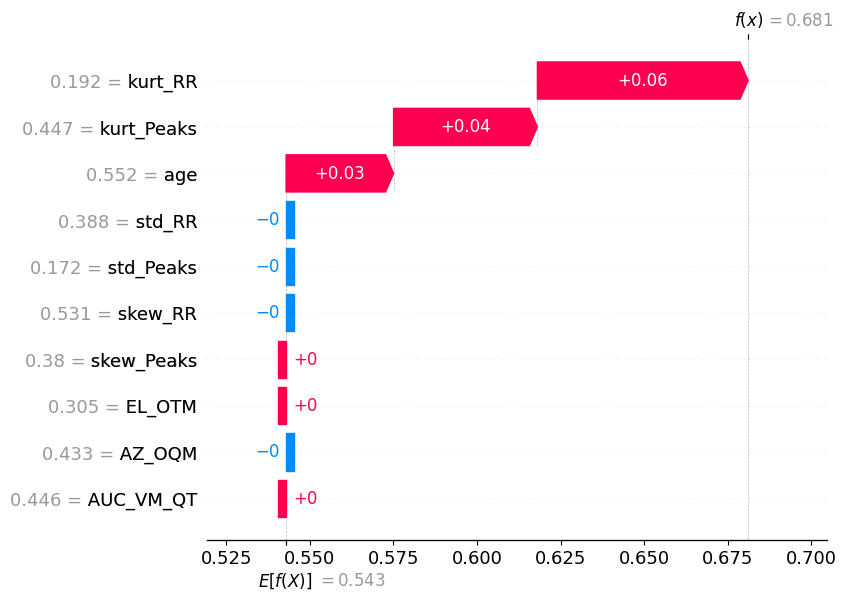



Explaining instance 1
True label:      0
Predicted label: 0


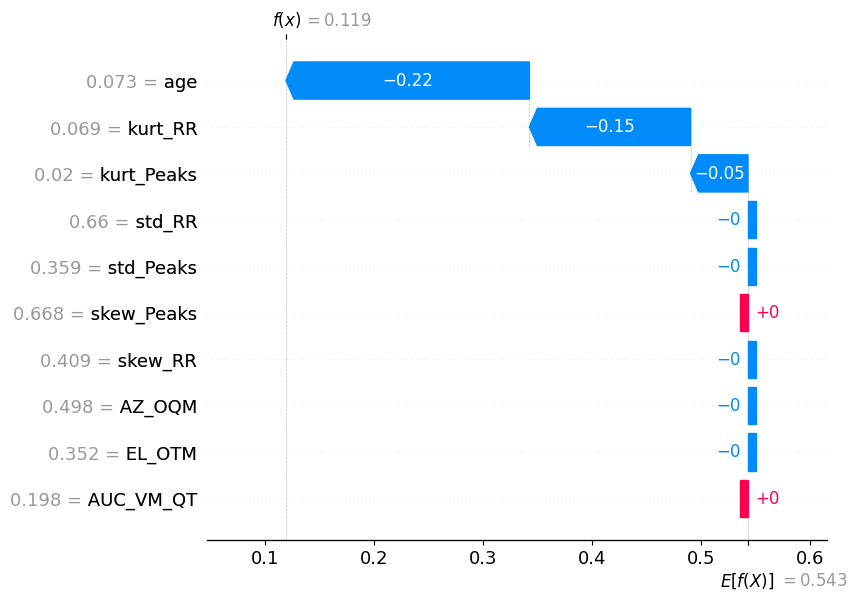



Explaining instance 2
True label:      1
Predicted label: 1


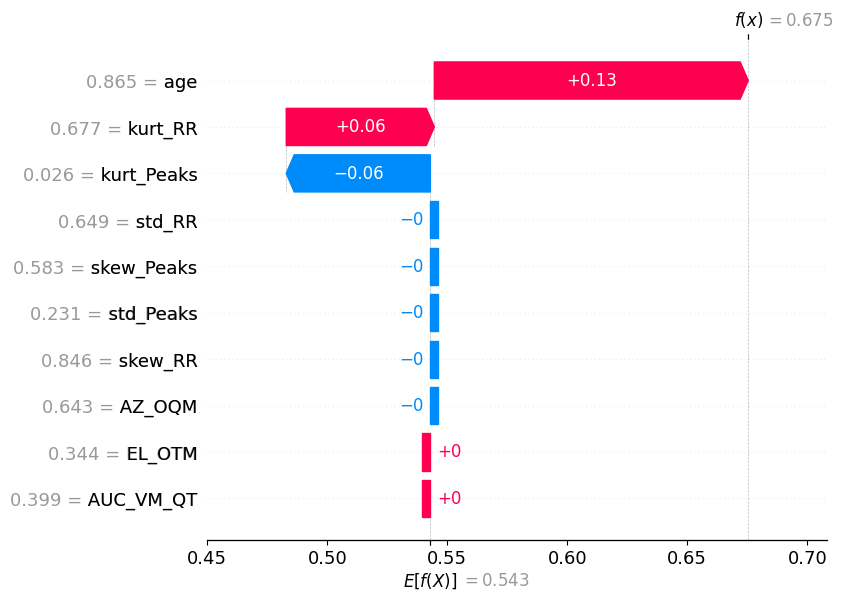

In [53]:
# Get predictions
pred_labels = best_model.predict(training_features)

# Plot local interpretability for 3 samples
for i in range(3):
    true_label = training_labels.iloc[i] if hasattr(training_labels, 'iloc') else training_labels[i]
    predicted_label = pred_labels[i]

    print(f"\n\nExplaining instance {i}")
    print(f"True label:      {true_label}")
    print(f"Predicted label: {predicted_label}")

    shap.plots.waterfall(shap_values[i])